# Anàlisi estadística - BBF-14 (mètriques AF3 + Rosetta)

Aquest notebook realitza l'anàlisi estadística completa sobre el dataset BBF-14 integrat, que conté les mètriques computacionals d'AlphaFold3, de Rosetta Relax i les mètriques d'interfície de Rosetta calculades sobre els 14 complexos del target.

L'objectiu és avaluar si aquestes mètriques permeten discriminar els dissenys que s'uneixen experimentalment al target (binders) dels que no ho fan (non-binders). L'anàlisi s'estructura en cinc blocs: descripció i preparació del dataset, discriminació univariant mètrica per mètrica (Mann-Whitney amb correcció FDR), estudi de la redundància i col·linealitat (matriu de correlació i VIF), model predictiu multivariant (regressió logística amb LOOCV i random forest) i anàlisi de robustesa (sensibilitat als outliers).

In [5]:
import ast
import pandas as pd
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import math
from pathlib import Path
from IPython.display import display


## Càrrega del dataset i observació global

Es carrega el dataset integrat final_bbf14.csv, que conté les mètriques d'AlphaFold3 (iPTM, pTM, ranking score, PAE cross-chain), les energies de Rosetta Relax i les mètriques d'interfície de Rosetta (ΔG, ΔSASA, packstat, hbonds, complementarietat de forma). Les columnes de mètriques de cadena (summary_chain_pair_pae_min, summary_chain_pair_pae_cross_chain) s'extreuen de la representació matricial i es redueixen a un valor escalar per complex. S'afegeix l'etiqueta de classificació (Binding = 1 binder, 0 non-binder) i el nom de cada disseny.

In [6]:
BASE = Path('/Users/bertaguiu/projects/Scripts/bbf14')
INPUT_CSV = BASE / 'final_bbf14.csv'
OUTPUT_DIR = BASE / 'final_bbf14_bindcraft_style_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)


def parse_cross_chain_from_matrix(value, reducer='mean'):
    if pd.isna(value):
        return np.nan

    try:
        parsed = ast.literal_eval(value) if isinstance(value, str) else value
        arr = np.asarray(parsed, dtype=float)
    except (ValueError, SyntaxError, TypeError):
        return np.nan

    if arr.ndim != 2 or arr.shape[0] < 2 or arr.shape[1] < 2:
        return np.nan

    off_diag = np.array([arr[0, 1], arr[1, 0]], dtype=float)
    if reducer == 'min':
        return float(np.nanmin(off_diag))
    if reducer == 'max':
        return float(np.nanmax(off_diag))
    return float(np.nanmean(off_diag))


df = pd.read_csv(INPUT_CSV)
# CODEX EDIT 2026-04-27: ordenar Complex1...Complex14 numèricament
df = df.sort_values('model', key=lambda s: s.str.extract(r'(\d+)').astype(int)[0]).reset_index(drop=True)

# CODEX EDIT 2026-04-27: derivar mètriques PAE cross-chain
df['summary_chain_pair_pae_cross_chain_mean'] = df['summary_chain_pair_pae_min'].apply(lambda x: parse_cross_chain_from_matrix(x, reducer='mean'))
df['summary_chain_pair_pae_cross_chain_min'] = df['summary_chain_pair_pae_min'].apply(lambda x: parse_cross_chain_from_matrix(x, reducer='min'))

df['Binding'] = pd.array(df['binding'], dtype='Int64')
df['Target'] = 'BBF-14'
df['DesignName'] = df['model']

df_labeled = df[df['Binding'].notna()].copy()

print(df.head())
print(df['Binding'].value_counts(dropna=False))
print(len(df))
print('\nDataset amb labels:')
print(df_labeled['Binding'].value_counts().sort_index())
display(df_labeled[['model', 'Binding', 'summary_chain_pair_pae_cross_chain_mean']])


      model  seed  sample  binding  ranking_score summary_chain_iptm  \
0  Complex1     1       3      0.0       0.857156       [0.82, 0.82]   
1  Complex2     1       2      0.0       0.762274       [0.72, 0.72]   
2  Complex3     1       2      0.0       0.813006       [0.76, 0.76]   
3  Complex4     1       0      0.0       0.360429       [0.28, 0.28]   
4  Complex5     1       0      0.0       0.324310       [0.23, 0.23]   

        summary_chain_pair_iptm      summary_chain_pair_pae_min  \
0  [[0.75, 0.82], [0.82, 0.83]]     [[0.76, 1.31], [1.2, 0.76]]   
1   [[0.74, 0.72], [0.72, 0.8]]    [[0.76, 1.91], [1.52, 0.76]]   
2  [[0.77, 0.76], [0.76, 0.79]]    [[0.76, 1.78], [1.66, 0.76]]   
3  [[0.71, 0.28], [0.28, 0.91]]   [[0.76, 10.86], [8.57, 0.76]]   
4  [[0.71, 0.23], [0.23, 0.81]]  [[0.76, 14.23], [12.22, 0.76]]   

  summary_chain_ptm  summary_fraction_disordered  ...  \
0      [0.75, 0.83]                         0.06  ...   
1       [0.74, 0.8]                         0.05  

,model,Binding,summary_chain_pair_pae_cross_chain_mean
0,Complex1,0,1.255
1,Complex2,0,1.715
2,Complex3,0,1.720
3,Complex4,0,9.715
4,Complex5,0,13.225
5,Complex6,1,1.410
6,Complex7,1,1.140
7,Complex8,1,1.475
8,Complex9,1,1.365
9,Complex10,1,6.475


## Selecció i normalització de les mètriques numèriques

Es seleccionen les columnes numèriques rellevants excloent les variables binàries i les de comptatge (seed, sample, n_structures). Posteriorment s'aplica una normalització Min-Max que transforma cada mètrica a l'interval [0, 1], necessària per comparar visualment i estadísticament mètriques amb unitats i rangs molt dispars (per exemple, energies de Rosetta en REU vs. valors iPTM entre 0 i 1).

In [7]:
EXCLUDE_NUMERIC_COLS = {
    'seed',
    'sample',
    'binding',
    'Binding',
    'rosetta_n_structures',
    'binding_n_structures',
}


def get_numeric_metric_columns(df, exclude_cols=None, verbose=True):
    if exclude_cols is None:
        exclude_cols = EXCLUDE_NUMERIC_COLS

    candidate_cols = [c for c in df.columns if c not in exclude_cols]
    df_num = df[candidate_cols].apply(pd.to_numeric, errors='coerce')

    numeric_cols = [c for c in df_num.columns if not df_num[c].isna().all()]
    numeric_cols = [c for c in numeric_cols if not set(df_num[c].dropna().unique()).issubset({0, 1})]
    numeric_cols = [c for c in numeric_cols if df_num[c].dropna().nunique() > 1]

    if verbose:
        print('=== MÈTRIQUES NUMÈRIQUES ===')
        print(f'Total: {len(numeric_cols)}')
        print(numeric_cols)

    return numeric_cols


metrics = get_numeric_metric_columns(df_labeled)

=== MÈTRIQUES NUMÈRIQUES ===
Total: 38
['ranking_score', 'summary_fraction_disordered', 'summary_iptm', 'summary_ptm', 'summary_ranking_score', 'rosetta_total_score_mean', 'rosetta_score_mean', 'rosetta_fa_atr_mean', 'rosetta_fa_dun_mean', 'rosetta_fa_elec_mean', 'rosetta_fa_intra_rep_mean', 'rosetta_fa_intra_sol_xover4_mean', 'rosetta_fa_rep_mean', 'rosetta_fa_sol_mean', 'rosetta_hbond_bb_sc_mean', 'rosetta_hbond_lr_bb_mean', 'rosetta_hbond_sc_mean', 'rosetta_hbond_sr_bb_mean', 'rosetta_lk_ball_wtd_mean', 'rosetta_omega_mean', 'rosetta_p_aa_pp_mean', 'rosetta_pro_close_mean', 'rosetta_rama_prepro_mean', 'rosetta_ref_mean', 'rosetta_time_mean', 'rosetta_yhh_planarity_mean', 'binding_interface_score_A_B_mean', 'binding_interface_dG_A_B_mean', 'binding_interface_delta_sasa_A_B_mean', 'binding_interface_packstat_A_B_mean', 'binding_interface_delta_hbond_unsat_A_B_mean', 'binding_interface_nres_A_B_mean', 'binding_interface_hbonds_A_B_mean', 'binding_interface_sc_A_B_mean', 'binding_interf

In [8]:
def normalize_dataset_minmax(df, feature_cols, exclude_cols=('Binding',)):
    """
    Normalitza entre 0 i 1 totes les columnes numèriques indicades a feature_cols.
    Manté intactes la resta de columnes del dataframe.
    """
    df_norm = df.copy()
    df_num = df_norm[feature_cols].apply(pd.to_numeric, errors='coerce')

    for col in feature_cols:
        col_min = df_num[col].min(skipna=True)
        col_max = df_num[col].max(skipna=True)

        if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
            df_norm[col] = 0.0
        else:
            df_norm[col] = (df_num[col] - col_min) / (col_max - col_min)

    return df_norm


df_labeled_norm = normalize_dataset_minmax(df_labeled, metrics)
display(df_labeled_norm[['model', 'Binding'] + metrics].head())

,model,Binding,ranking_score,summary_fraction_disordered,summary_iptm,summary_ptm,summary_ranking_score,rosetta_total_score_mean,rosetta_score_mean,rosetta_fa_atr_mean,...,binding_interface_delta_sasa_A_B_mean,binding_interface_packstat_A_B_mean,binding_interface_delta_hbond_unsat_A_B_mean,binding_interface_nres_A_B_mean,binding_interface_hbonds_A_B_mean,binding_interface_sc_A_B_mean,binding_interface_dG_dSASA_ratio_A_B_mean,binding_interface_total_hbond_E_A_B_mean,summary_chain_pair_pae_cross_chain_mean,summary_chain_pair_pae_cross_chain_min
0,Complex1,0,0.960048,0.500000,0.936508,0.857143,0.964286,0.905998,0.905998,0.973687,...,0.069487,1.000000,0.000000,0.314959,0.090810,0.858908,0.195017,1.000000,0.009516,0.013429
1,Complex2,0,0.789096,0.333333,0.777778,0.714286,0.785714,0.589127,0.589127,0.581106,...,0.000000,0.356233,0.236181,0.000000,0.152079,0.501104,0.000000,0.920867,0.047580,0.042077
2,Complex3,0,0.880501,1.000000,0.841270,0.750000,0.875000,0.716103,0.716103,0.845930,...,0.369141,0.357589,0.597272,0.512682,0.295405,0.985194,0.328383,0.862955,0.047993,0.054611
3,Complex4,0,0.065077,0.000000,0.079365,0.142857,0.071429,0.252927,0.252927,0.213119,...,0.619050,0.820732,0.927495,0.752347,0.215536,0.422384,0.677576,0.802829,0.709557,0.673232
4,Complex5,0,0.000000,0.166667,0.000000,0.000000,0.000000,0.219578,0.219578,0.270454,...,0.473187,0.748609,1.000000,0.587178,0.000000,0.619530,0.583149,0.949759,1.000000,1.000000


## Boxplot ordenat per p-value (Mann-Whitney) sobre dades normalitzades

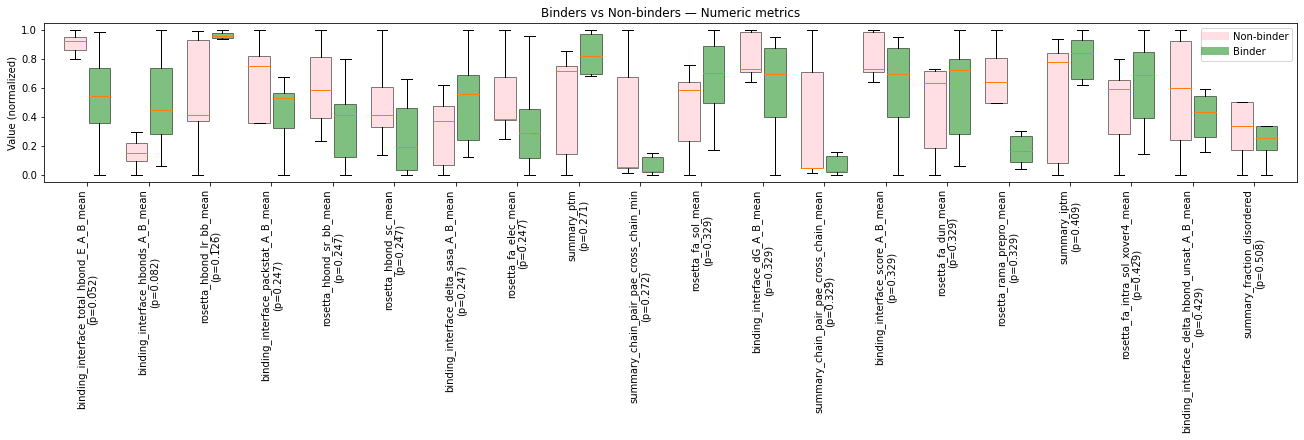

,feature,p_value
0,binding_interface_total_hbond_E_A_B_mean,0.051948
1,binding_interface_hbonds_A_B_mean,0.082251
2,rosetta_hbond_lr_bb_mean,0.125541
3,binding_interface_packstat_A_B_mean,0.246753
4,rosetta_hbond_sr_bb_mean,0.246753
5,rosetta_hbond_sc_mean,0.246753
6,binding_interface_delta_sasa_A_B_mean,0.246753
7,rosetta_fa_elec_mean,0.246753
8,summary_ptm,0.271132
9,summary_chain_pair_pae_cross_chain_min,0.272229


In [9]:
def boxplot_binding_numeric(
    df_plot,
    df_stats,
    feature_cols,
    binding_col='Binding',
    alpha=0.05,
    top_k=20,
    showfliers=False,
    figsize=(18, 6),
):
    """
    Boxplot sobre dades normalitzades, però ordenat pel p-value del test de Mann-Whitney
    calculat sobre les dades sense normalitzar.
    """

    mask_b_stats = df_stats[binding_col] == 1
    mask_nb_stats = df_stats[binding_col] == 0
    mask_b_plot = df_plot[binding_col] == 1
    mask_nb_plot = df_plot[binding_col] == 0

    rows = []
    for c in feature_cols:
        xb = pd.to_numeric(df_stats.loc[mask_b_stats, c], errors='coerce').dropna().values
        xnb = pd.to_numeric(df_stats.loc[mask_nb_stats, c], errors='coerce').dropna().values

        if len(xb) < 2 or len(xnb) < 2:
            p = np.nan
        else:
            p = mannwhitneyu(xnb, xb, alternative='two-sided').pvalue

        rows.append((c, p))

    pvals = pd.DataFrame(rows, columns=['feature', 'p_value'])
    pvals = pvals.sort_values('p_value', na_position='last').reset_index(drop=True)

    significant = pvals[pvals['p_value'] < alpha]
    if len(significant) >= top_k:
        plot_df = significant.iloc[:top_k].copy()
    else:
        plot_df = pvals.iloc[:top_k].copy()

    plot_feats = plot_df['feature'].tolist()

    def fmt(p):
        if pd.isna(p):
            return 'NA'
        return f'{p:.1e}' if p < 0.001 else f'{p:.3f}'

    labels = [f"{f}\n(p={fmt(p)})" for f, p in zip(plot_df['feature'], plot_df['p_value'])]

    data_nb = [pd.to_numeric(df_plot.loc[mask_nb_plot, f], errors='coerce').dropna().values for f in plot_feats]
    data_b = [pd.to_numeric(df_plot.loc[mask_b_plot, f], errors='coerce').dropna().values for f in plot_feats]

    x = np.arange(len(plot_feats))
    pos_nb = x - 0.2
    pos_b = x + 0.2

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    bp_nb = ax.boxplot(data_nb, positions=pos_nb, widths=0.35, patch_artist=True, showfliers=showfliers)
    bp_b = ax.boxplot(data_b, positions=pos_b, widths=0.35, patch_artist=True, showfliers=showfliers)

    for patch in bp_nb['boxes']:
        patch.set_facecolor('pink')
        patch.set_alpha(0.5)

    for patch in bp_b['boxes']:
        patch.set_facecolor('green')
        patch.set_alpha(0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel('Value (normalized)')
    ax.set_title('Binders vs Non-binders — Numeric metrics')

    ax.plot([], [], color='pink', linewidth=8, alpha=0.5, label='Non-binder')
    ax.plot([], [], color='green', linewidth=8, alpha=0.5, label='Binder')
    ax.legend()

    plt.savefig(OUTPUT_DIR / 'boxplot_binding_normalized_mannwhitney.png', bbox_inches='tight')
    plt.show()

    return pvals


pvals_df = boxplot_binding_numeric(df_labeled_norm, df_labeled, metrics, top_k=min(20, len(metrics)))
display(pvals_df)
pvals_df.to_csv(OUTPUT_DIR / 'mannwhitney_pvalues_raw_order_for_normalized_boxplot.csv', index=False)


## Test de Mann-Whitney amb correcció FDR (Benjamini-Hochberg)

Es calcula el test de Mann-Whitney per a cada mètrica sobre les dades sense normalitzar, i s'afegeixen la mida de l'efecte (delta de Cliff) i l'AUC com a mesures complementàries. Posteriorment s'aplica la correcció FDR de Benjamini-Hochberg per controlar la taxa de falsos positius deguda a les comparacions múltiples.

In [10]:
# CODEX EDIT 2026-04-27: Mann-Whitney en dades raw + effect size + AUC
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan

    greater = sum(ix > iy for ix in x for iy in y)
    lower = sum(ix < iy for ix in x for iy in y)
    return (greater - lower) / (len(x) * len(y))


def compute_metric_auc(values, labels):
    sub = pd.DataFrame({'value': values, 'label': labels}).dropna()
    if sub['label'].nunique() < 2:
        return np.nan, np.nan

    from sklearn.metrics import roc_auc_score

    auc_raw = roc_auc_score(sub['label'].astype(int), sub['value'].astype(float))
    auc_best_direction = max(auc_raw, 1 - auc_raw)
    return auc_raw, auc_best_direction


def mannwhitney_with_effects_auc(df_target, feature_cols, binding_col='Binding'):
    mask_b = df_target[binding_col] == 1
    mask_nb = df_target[binding_col] == 0

    rows = []
    for c in feature_cols:
        xb = pd.to_numeric(df_target.loc[mask_b, c], errors='coerce').dropna().values
        xnb = pd.to_numeric(df_target.loc[mask_nb, c], errors='coerce').dropna().values
        all_values = pd.to_numeric(df_target[c], errors='coerce')
        all_labels = df_target[binding_col]

        if len(xb) < 2 or len(xnb) < 2:
            stat = np.nan
            p = np.nan
        else:
            stat, p = mannwhitneyu(xnb, xb, alternative='two-sided')

        auc_raw, auc_best = compute_metric_auc(all_values, all_labels)

        rows.append({
            'feature': c,
            'n_nonbinder': len(xnb),
            'n_binder': len(xb),
            'nonbinder_mean': np.mean(xnb) if len(xnb) else np.nan,
            'binder_mean': np.mean(xb) if len(xb) else np.nan,
            'u_statistic': stat,
            'p_value_raw': p,
            'cliffs_delta': cliffs_delta(xb, xnb),
            'auc_metric_raw_direction': auc_raw,
            'auc_metric_best_direction': auc_best,
        })

    results = pd.DataFrame(rows)
    results['p_value_fdr_bh'] = np.nan

    valid = results['p_value_raw'].notna()
    if valid.sum() > 0:
        results.loc[valid, 'p_value_fdr_bh'] = multipletests(results.loc[valid, 'p_value_raw'], method='fdr_bh')[1]

    results = results.sort_values(['p_value_raw', 'auc_metric_best_direction'], ascending=[True, False], na_position='last').reset_index(drop=True)
    return results


mannwhitney_fdr_df = mannwhitney_with_effects_auc(df_labeled, metrics)
display(mannwhitney_fdr_df)
mannwhitney_fdr_df.to_csv(OUTPUT_DIR / 'mannwhitney_raw_effectsize_auc_fdr.csv', index=False)


,feature,n_nonbinder,n_binder,nonbinder_mean,binder_mean,u_statistic,p_value_raw,cliffs_delta,auc_metric_raw_direction,auc_metric_best_direction,p_value_fdr_bh
0,binding_interface_total_hbond_E_A_B_mean,5,6,-5.102960,-9.282922,26.0,0.051948,-0.733333,0.133333,0.866667,0.781385
1,binding_interface_hbonds_A_B_mean,5,6,4.899099,7.798799,5.0,0.082251,0.666667,0.833333,0.833333,0.781385
2,rosetta_hbond_lr_bb_mean,5,6,-83.317789,-67.309410,6.0,0.125541,0.600000,0.800000,0.800000,0.781385
3,rosetta_fa_elec_mean,5,6,-488.623822,-534.624565,22.0,0.246753,-0.466667,0.266667,0.733333,0.781385
4,rosetta_hbond_sc_mean,5,6,-44.789151,-52.196170,22.0,0.246753,-0.466667,0.266667,0.733333,0.781385
5,rosetta_hbond_sr_bb_mean,5,6,-93.656703,-122.789282,22.0,0.246753,-0.466667,0.266667,0.733333,0.781385
6,binding_interface_packstat_A_B_mean,5,6,0.611062,0.594347,22.0,0.246753,-0.466667,0.266667,0.733333,0.781385
7,binding_interface_delta_sasa_A_B_mean,5,6,1915.445874,2256.394148,8.0,0.246753,0.466667,0.733333,0.733333,0.781385
8,summary_ptm,5,6,0.728000,0.795000,8.5,0.271132,0.433333,0.716667,0.716667,0.781385
9,summary_chain_pair_pae_cross_chain_min,5,6,5.034000,2.215000,21.5,0.272229,-0.433333,0.283333,0.716667,0.781385


## Violin + swarm plot amb dades sense normalitzar

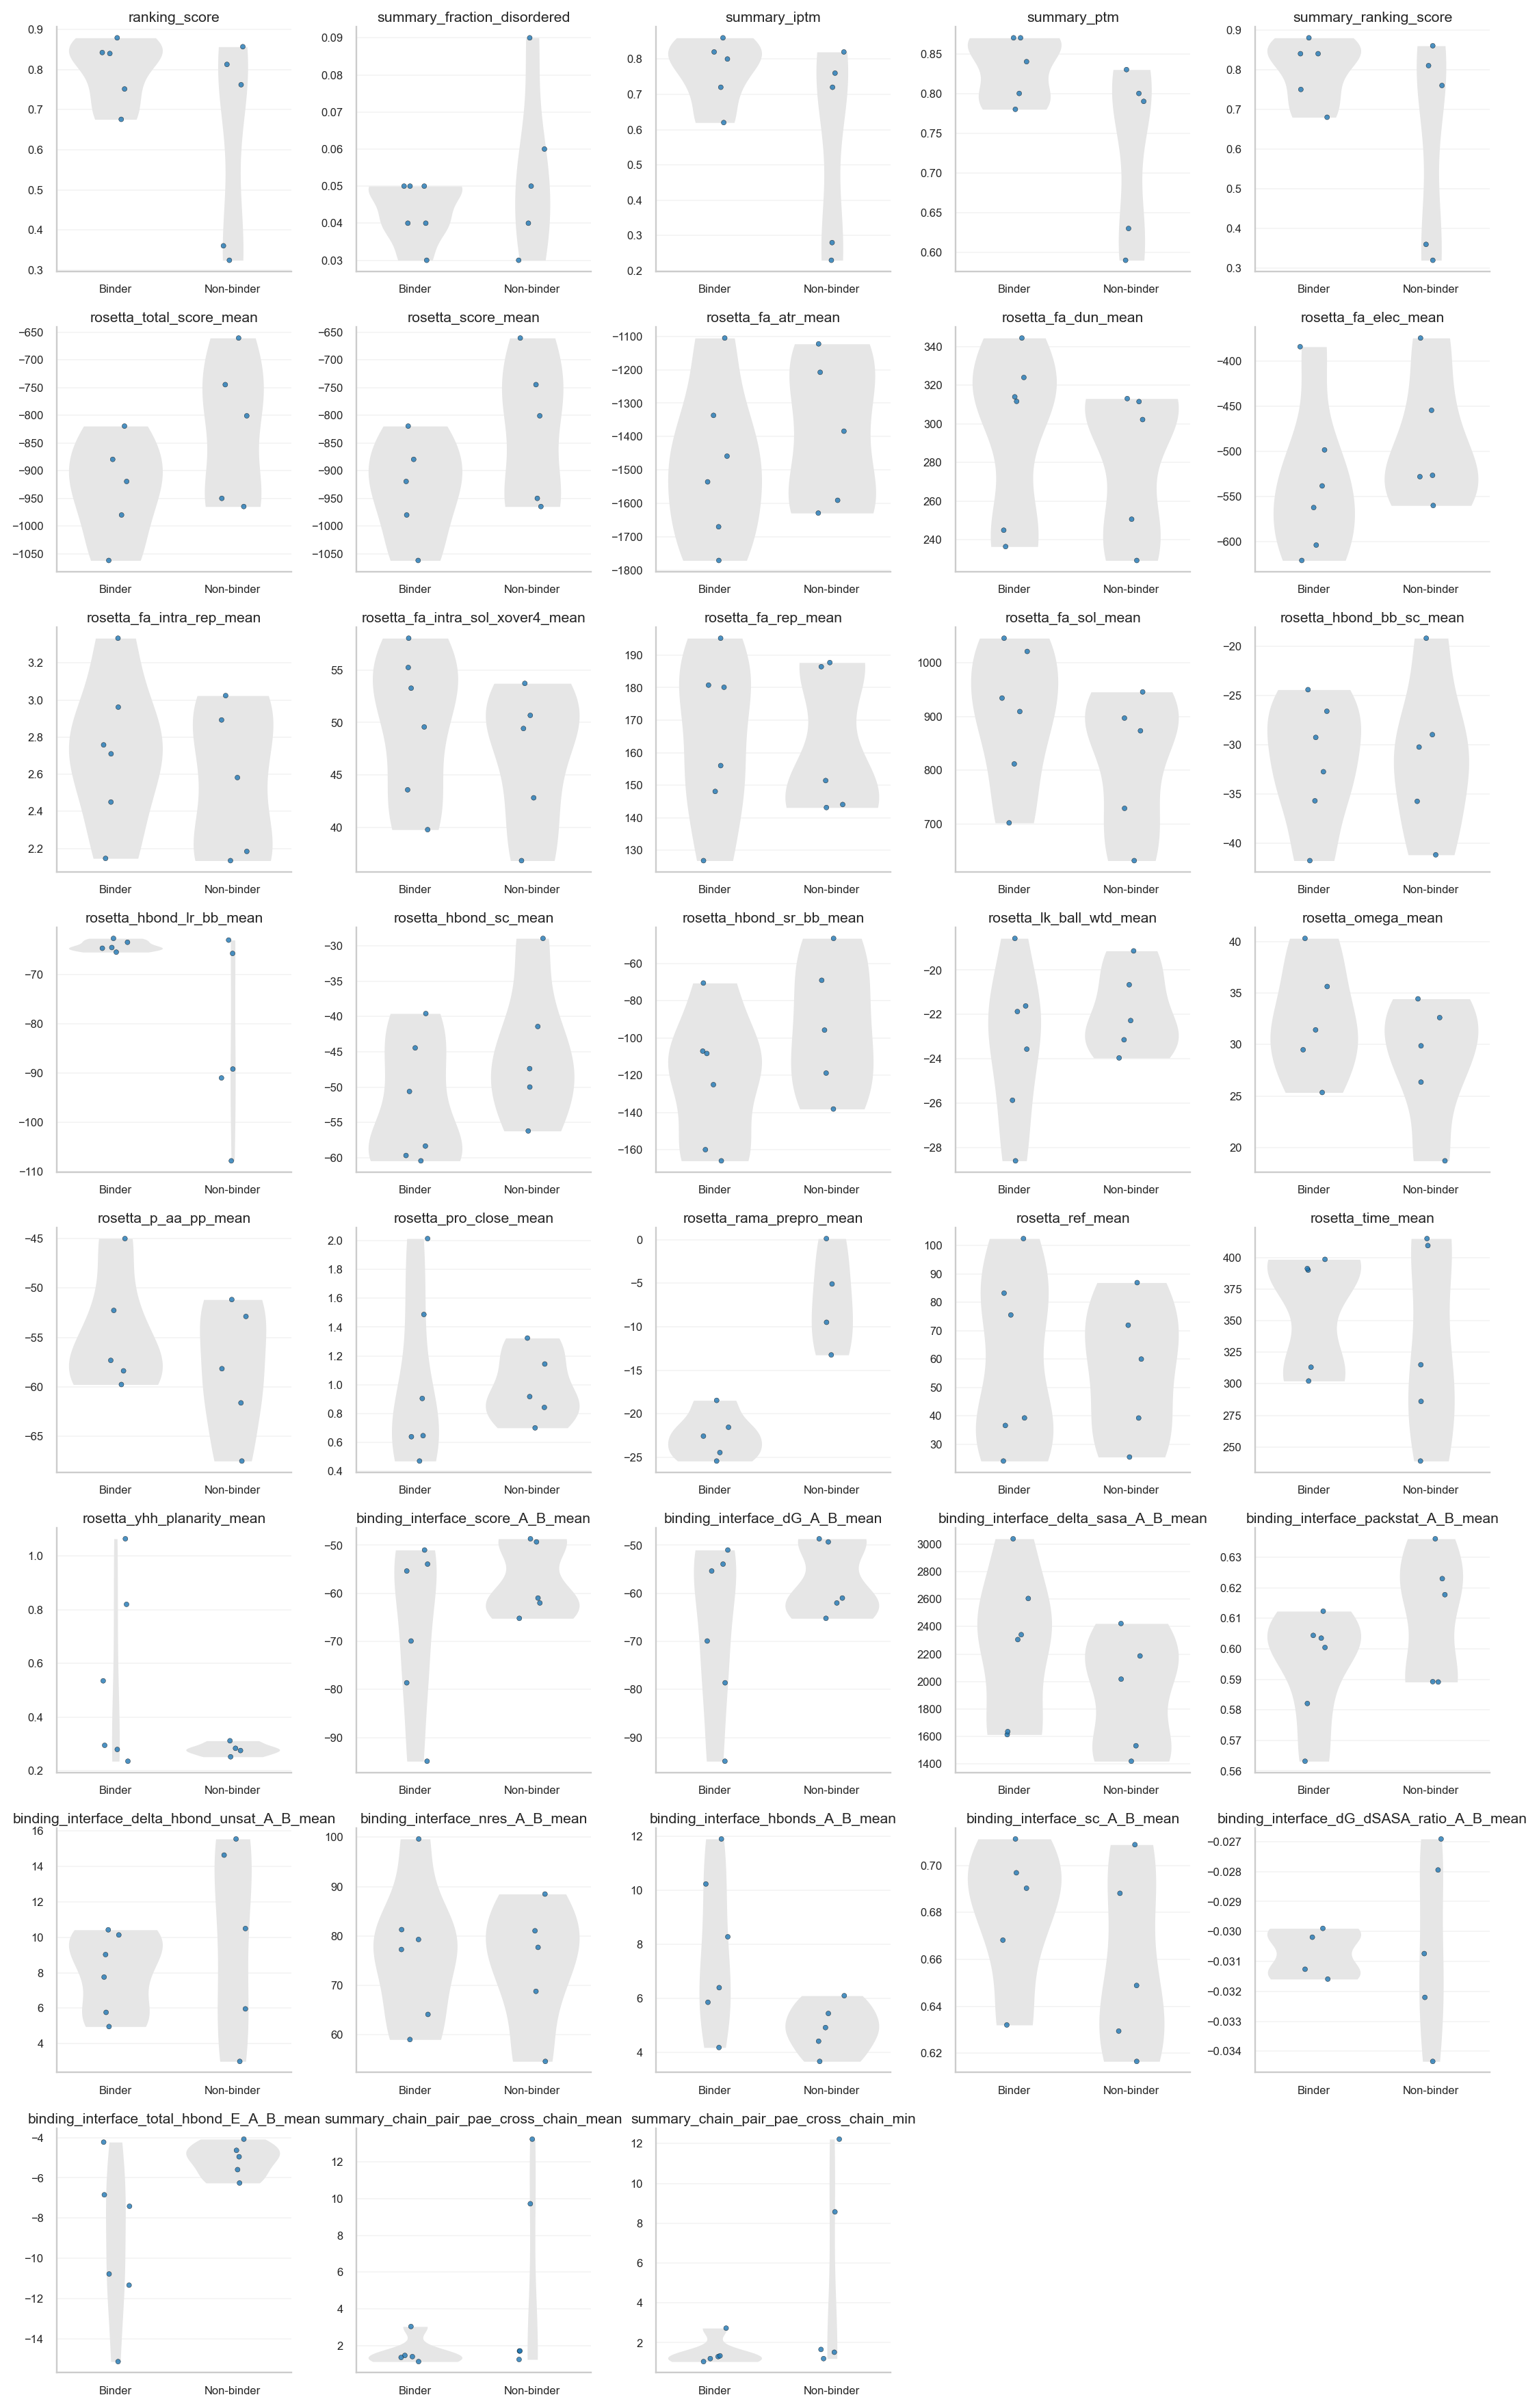

In [11]:
sns.set_theme(style='whitegrid', context='paper')

target_sel = 'BBF-14'
BIND_ORDER = ['Binder', 'Non-binder']

long = df_labeled[['Target', 'Binding'] + metrics].melt(
    id_vars=['Target', 'Binding'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Value'
).dropna(subset=['Value'])

long['Binding'] = long['Binding'].astype(int).map({1: 'Binder', 0: 'Non-binder'})
long['Binding'] = pd.Categorical(long['Binding'], categories=BIND_ORDER, ordered=True)

palette = {target_sel: sns.color_palette('tab20', n_colors=1)[0]}


def _iqr_filter_by_group(d, group_col='Binding', value_col='Value', k=1.5):
    parts = []
    for _, sub in d.groupby(group_col, dropna=False, observed=False):
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr):
            parts.append(sub)
            continue

        if iqr == 0:
            parts.append(sub[sub[value_col] <= q3])
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        parts.append(sub[(sub[value_col] >= lo) & (sub[value_col] <= hi)])

    return pd.concat(parts, axis=0)


ncols = 5
nplots = len(metrics)
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.6 * ncols, 2.6 * nrows),
    dpi=170
)

axes = np.array(axes).reshape(-1)

for i, m in enumerate(metrics):
    ax = axes[i]
    d = long[long['Metric'] == m].copy()
    d = _iqr_filter_by_group(d, group_col='Binding', value_col='Value', k=1.5)

    sns.violinplot(
        data=d,
        x='Binding',
        y='Value',
        order=BIND_ORDER,
        inner=None,
        cut=0,
        linewidth=0,
        color='0.90',
        bw_adjust=0.8,
        gridsize=200,
        ax=ax
    )

    sns.stripplot(
        data=d,
        x='Binding',
        y='Value',
        order=BIND_ORDER,
        hue='Target',
        hue_order=[target_sel],
        palette=palette,
        jitter=0.12,
        size=3.0,
        alpha=0.80,
        linewidth=0.2,
        edgecolor='black',
        ax=ax
    )

    ax.set_title(m, fontsize=9, pad=3)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(axis='y', alpha=0.20)
    ax.grid(axis='x', visible=False)
    sns.despine(ax=ax)

    if ax.legend_ is not None:
        ax.legend_.remove()

for j in range(nplots, len(axes)):
    fig.delaxes(axes[j])

fig.subplots_adjust(hspace=0.40, wspace=0.30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'violin_swarm_raw_metrics.png', bbox_inches='tight')
plt.show()

## Funcions per a la regressió logística

In [12]:
def keep_selected_metrics(
    df,
    feature_cols,
    keep_cols=None,
    label_col='Binding',
    verbose=True
):
    df = df.copy()

    if keep_cols is None:
        keep_cols = ['Target', 'DesignName', 'model', 'seed', 'sample']

    cols_to_keep = [c for c in keep_cols if c in df.columns]
    if label_col in df.columns:
        cols_to_keep.append(label_col)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Falten aquestes features al dataframe: {missing}')

    final_cols = cols_to_keep + [c for c in feature_cols if c not in cols_to_keep]
    df_filtered = df[final_cols].copy()

    if verbose:
        print('=== FILTRAT DE COLUMNES ===')
        print(f'Columnes totals inicials: {df.shape[1]}')
        print(f'Columnes finals: {df_filtered.shape[1]}')
        print('Mètriques seleccionades:')
        print(feature_cols)

    return df_filtered, feature_cols

In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


def normalize_metrics(
    df,
    feature_cols,
    label_col='Binding',
    nan_strategy='median',
    verbose=True
):
    """
    Normalitza només les feature_cols per a la regressió logística.
    Gestiona NaNs amb 'drop' o 'median'.
    """

    df = df.copy()

    missing_features = [c for c in feature_cols if c not in df.columns]
    if missing_features:
        raise ValueError(f'Falten aquestes features al dataframe: {missing_features}')

    if label_col not in df.columns:
        raise ValueError(f"No existeix la columna '{label_col}' al dataframe.")

    nan_counts = df[feature_cols].isna().sum()
    nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

    if verbose:
        print('\n=== NORMALITZACIÓ ===')
        print(f'Files inicials: {len(df)}')
        if len(nan_counts) > 0:
            print('Columnes amb NaNs:')
            print(nan_counts)
        else:
            print('No hi ha NaNs a les features seleccionades.')

    imputer = None

    if nan_strategy == 'drop':
        before = len(df)
        df = df.dropna(subset=feature_cols + [label_col]).copy()
        after = len(df)

        if verbose:
            print('\nEstratègia NaN: DROP')
            print(f'Files eliminades: {before - after}')
            print(f'Files finals: {after}')

    elif nan_strategy == 'median':
        before = len(df)
        df = df.dropna(subset=[label_col]).copy()
        after = len(df)

        imputer = SimpleImputer(strategy='median')
        df[feature_cols] = imputer.fit_transform(df[feature_cols])

        if verbose:
            print('\nEstratègia NaN: MEDIAN')
            print(f'Files eliminades per label NaN: {before - after}')
            print(f'Files finals: {after}')

    else:
        raise ValueError("nan_strategy ha de ser 'drop' o 'median'.")

    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    if verbose:
        print('Normalització completada.')

    return df, scaler, imputer

In [14]:
def logistic_regression_visual(
    df,
    label_col='Binding',
    design_col='DesignName',
    target_col='Target',
    max_iter=3000,
    verbose=True,
    penalty='l1',
    c_grid=(0.001, 0.01, 0.1),
    permutation_n=1000,
    random_state=42,
    run_permutation=True,
    output_dir=OUTPUT_DIR,
    output_prefix='logistic_regression',
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import LeaveOneOut, permutation_test_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        confusion_matrix,
        ConfusionMatrixDisplay,
        roc_curve,
        roc_auc_score,
        classification_report,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
    )

    df = df.copy()

    selected_features = [
        'ranking_score',
        'summary_iptm',
        'summary_ptm',
        'summary_ranking_score',
        'summary_chain_pair_pae_cross_chain_mean',
        'rosetta_total_score_mean',
        'rosetta_fa_atr_mean',
        'rosetta_fa_elec_mean',
        'binding_interface_dG_A_B_mean',
        'binding_interface_delta_sasa_A_B_mean',
        'binding_interface_packstat_A_B_mean',
        'binding_interface_hbonds_A_B_mean',
        'binding_interface_sc_A_B_mean',
        'binding_interface_total_hbond_E_A_B_mean',
    ]

    feature_cols = [c for c in selected_features if c in df.columns]

    if len(feature_cols) == 0:
        raise ValueError('Cap de les mètriques seleccionades existeix al dataframe.')

    if label_col not in df.columns:
        raise ValueError(f"No existeix la columna '{label_col}' al dataframe.")

    df = df.dropna(subset=feature_cols + [label_col]).copy()
    X = df[feature_cols].apply(pd.to_numeric, errors='coerce')
    y = df[label_col].astype(int)

    if len(y.unique()) < 2:
        raise ValueError('La regressió logística necessita dues classes.')

    loo = LeaveOneOut()

    def run_loocv_for_c(C_value):
        y_true_all = []
        y_pred_all = []
        y_proba_all = []
        test_indices = []
        coef_list = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if len(np.unique(y_train)) < 2:
                continue

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(
                    penalty=penalty,
                    C=C_value,
                    solver='liblinear',
                    max_iter=max_iter,
                    random_state=random_state,
                ))
            ])
            pipe.fit(X_train, y_train)

            y_pred = pipe.predict(X_test)[0]
            y_proba = pipe.predict_proba(X_test)[0, 1]

            y_true_all.append(y_test.iloc[0])
            y_pred_all.append(y_pred)
            y_proba_all.append(y_proba)
            test_indices.append(X_test.index[0])
            coef_list.append(pipe.named_steps['clf'].coef_[0])

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        y_proba_all = np.array(y_proba_all)

        acc = accuracy_score(y_true_all, y_pred_all)
        prec = precision_score(y_true_all, y_pred_all, zero_division=0)
        rec = recall_score(y_true_all, y_pred_all, zero_division=0)
        f1 = f1_score(y_true_all, y_pred_all, zero_division=0)
        auc = roc_auc_score(y_true_all, y_proba_all) if len(np.unique(y_true_all)) == 2 else np.nan

        coef_array = np.array(coef_list)
        coef_df = pd.DataFrame({
            'Metric': feature_cols,
            'Coefficient_mean': coef_array.mean(axis=0),
            'Coefficient_std': coef_array.std(axis=0),
        })
        coef_df['AbsCoefficient_mean'] = coef_df['Coefficient_mean'].abs()
        coef_df = coef_df.sort_values('Coefficient_mean').reset_index(drop=True)

        pred_cols = []
        if target_col in df.columns:
            pred_cols.append(target_col)
        if design_col in df.columns:
            pred_cols.append(design_col)

        pred_df = df.loc[test_indices, pred_cols + [label_col]].copy()
        pred_df['PredictedClass'] = y_pred_all
        pred_df['PredictedProbability_Binder'] = y_proba_all
        pred_df['CorrectPrediction'] = pred_df[label_col].astype(int).values == pred_df['PredictedClass'].values
        pred_df = pred_df.sort_values('PredictedProbability_Binder', ascending=False).reset_index(drop=True)

        return {
            'C': C_value,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'auc': auc,
            'coef_df': coef_df,
            'pred_df': pred_df,
            'y_true_all': y_true_all,
            'y_pred_all': y_pred_all,
            'y_proba_all': y_proba_all,
        }

    grid_results = [run_loocv_for_c(C_value) for C_value in c_grid]
    grid_results_df = pd.DataFrame([
        {
            'C': res['C'],
            'accuracy': res['accuracy'],
            'precision': res['precision'],
            'recall': res['recall'],
            'f1': res['f1'],
            'auc': res['auc'],
        }
        for res in grid_results
    ])
    grid_results_df = grid_results_df.sort_values(['auc', 'accuracy', 'f1'], ascending=False, na_position='last').reset_index(drop=True)
    best_c = grid_results_df.iloc[0]['C']
    best_res = next(res for res in grid_results if res['C'] == best_c)

    if verbose:
        print('\n=== MÈTRIQUES UTILITZADES EN LA REGRESSIÓ ===')
        for f in feature_cols:
            print(f)
        print('\n=== DISTRIBUCIÓ DE CLASSES ===')
        print(y.value_counts().sort_index())
        print('\n=== REGULARITZACIÓ FORTA ===')
        print(f'Penalty: {penalty}')
        print(f'C grid: {list(c_grid)}')
        print('\n=== RESULTATS PER C ===')
        display(grid_results_df)
        print(f'\nMillor C seleccionat: {best_c}')
        print('\n=== VALIDACIÓ ===')
        print("S'utilitza Leave-One-Out Cross Validation (LOOCV) amb Pipeline(StandardScaler + LogisticRegression).")
        print('\n=== RESULTATS GLOBALS LOOCV ===')
        print(f"Accuracy : {best_res['accuracy']:.3f}")
        print(f"Precision: {best_res['precision']:.3f}")
        print(f"Recall   : {best_res['recall']:.3f}")
        print(f"F1-score : {best_res['f1']:.3f}")
        print(f"AUC      : {best_res['auc']:.3f}")
        print('\n=== CLASSIFICATION REPORT ===')
        print(classification_report(best_res['y_true_all'], best_res['y_pred_all'], zero_division=0))

    permutation_score = np.nan
    permutation_pvalue = np.nan
    perm_scores = np.array([])
    if run_permutation:
        best_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                penalty=penalty,
                C=best_c,
                solver='liblinear',
                max_iter=max_iter,
                random_state=random_state,
            ))
        ])
        permutation_score, perm_scores, permutation_pvalue = permutation_test_score(
            best_pipeline,
            X,
            y,
            cv=loo,
            scoring='accuracy',
            n_permutations=permutation_n,
            random_state=random_state,
            n_jobs=1,
        )

    coef_plot = best_res['coef_df'].sort_values('Coefficient_mean')
    fpr, tpr, _ = roc_curve(best_res['y_true_all'], best_res['y_proba_all'])

    fig_grid, ax_grid = plt.subplots(figsize=(6, 4.5), dpi=170)
    plot_df = grid_results_df.melt(id_vars='C', value_vars=['accuracy', 'f1', 'auc'], var_name='metric', value_name='value')
    sns.lineplot(data=plot_df, x='C', y='value', hue='metric', marker='o', ax=ax_grid)
    ax_grid.set_xscale('log')
    ax_grid.set_title('LOOCV performance by C')
    ax_grid.set_ylabel('Score')
    ax_grid.set_xlabel('C')
    plt.tight_layout()
    fig_grid.savefig(output_dir / f'{output_prefix}_grid_search.png', bbox_inches='tight')
    plt.show()
    plt.close(fig_grid)

    fig_coef, ax_coef = plt.subplots(figsize=(8, 6), dpi=170)
    sns.barplot(data=coef_plot, x='Coefficient_mean', y='Metric', ax=ax_coef)
    ax_coef.axvline(0, linestyle='--', linewidth=1, color='black')
    ax_coef.set_title(f'Coeficients mitjans L1 logistic (LOOCV, C={best_c})')
    ax_coef.set_xlabel('Coeficient mitjà')
    ax_coef.set_ylabel('Mètrica')
    plt.tight_layout()
    fig_coef.savefig(output_dir / f'{output_prefix}_coefficients.png', bbox_inches='tight')
    plt.show()
    plt.close(fig_coef)

    fig_cm, ax_cm = plt.subplots(figsize=(5, 4.5), dpi=170)
    cm = confusion_matrix(best_res['y_true_all'], best_res['y_pred_all'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-binder', 'Binder'])
    disp.plot(ax=ax_cm, colorbar=False)
    ax_cm.set_title('Confusion matrix global (LOOCV)')
    plt.tight_layout()
    fig_cm.savefig(output_dir / f'{output_prefix}_confusion_matrix.png', bbox_inches='tight')
    plt.show()
    plt.close(fig_cm)

    fig_roc, ax_roc = plt.subplots(figsize=(5.5, 4.5), dpi=170)
    ax_roc.plot(fpr, tpr, label=f"AUC = {best_res['auc']:.3f}")
    ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax_roc.set_title('ROC curve global (LOOCV)')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()
    plt.tight_layout()
    fig_roc.savefig(output_dir / f'{output_prefix}_roc_curve.png', bbox_inches='tight')
    plt.show()
    plt.close(fig_roc)

    fig_perm, ax_perm = plt.subplots(figsize=(6, 4.5), dpi=170)
    if run_permutation and len(perm_scores) > 0:
        ax_perm.hist(perm_scores, bins=20, alpha=0.75)
        ax_perm.axvline(permutation_score, color='red', linestyle='--', linewidth=1.5)
        ax_perm.set_title(f'Permutation test (accuracy)\np={permutation_pvalue:.3f}')
        ax_perm.set_xlabel('Permutation accuracy')
        ax_perm.set_ylabel('Count')
        perm_filename = f'{output_prefix}_permutation_test.png'
    else:
        bins = np.linspace(0, 1, 12)
        ax_perm.hist(best_res['y_proba_all'][best_res['y_true_all'] == 0], bins=bins, alpha=0.7, label='Non-binder')
        ax_perm.hist(best_res['y_proba_all'][best_res['y_true_all'] == 1], bins=bins, alpha=0.7, label='Binder')
        ax_perm.axvline(0.5, linestyle='--', linewidth=1, color='black')
        ax_perm.set_title('Probabilitat predita de binding (LOOCV)')
        ax_perm.set_xlabel('P(Binder)')
        ax_perm.set_ylabel('Nombre de mostres')
        ax_perm.legend()
        perm_filename = f'{output_prefix}_probability_histogram.png'
    plt.tight_layout()
    fig_perm.savefig(output_dir / perm_filename, bbox_inches='tight')
    plt.show()
    plt.close(fig_perm)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11), dpi=170)
    axes = axes.flatten()
    sns.barplot(data=coef_plot, x='Coefficient_mean', y='Metric', ax=axes[0])
    axes[0].axvline(0, linestyle='--', linewidth=1, color='black')
    axes[0].set_title(f'Coeficients mitjans L1 logistic (LOOCV, C={best_c})')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-binder', 'Binder'])
    disp.plot(ax=axes[1], colorbar=False)
    axes[1].set_title('Confusion matrix global (LOOCV)')
    axes[2].plot(fpr, tpr, label=f"AUC = {best_res['auc']:.3f}")
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[2].set_title('ROC curve global (LOOCV)')
    axes[2].legend()
    if run_permutation and len(perm_scores) > 0:
        axes[3].hist(perm_scores, bins=20, alpha=0.75)
        axes[3].axvline(permutation_score, color='red', linestyle='--', linewidth=1.5)
        axes[3].set_title(f'Permutation test (accuracy)\np={permutation_pvalue:.3f}')
    else:
        bins = np.linspace(0, 1, 12)
        axes[3].hist(best_res['y_proba_all'][best_res['y_true_all'] == 0], bins=bins, alpha=0.7, label='Non-binder')
        axes[3].hist(best_res['y_proba_all'][best_res['y_true_all'] == 1], bins=bins, alpha=0.7, label='Binder')
        axes[3].axvline(0.5, linestyle='--', linewidth=1, color='black')
        axes[3].legend()
        axes[3].set_title('Probabilitat predita de binding (LOOCV)')
    plt.tight_layout()
    fig.savefig(output_dir / f'{output_prefix}_summary_panel.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)

    return {
        'feature_cols': feature_cols,
        'coefficients': best_res['coef_df'],
        'predictions': best_res['pred_df'],
        'accuracy': best_res['accuracy'],
        'precision': best_res['precision'],
        'recall': best_res['recall'],
        'f1': best_res['f1'],
        'auc': best_res['auc'],
        'best_c': best_c,
        'penalty': penalty,
        'grid_results_df': grid_results_df,
        'permutation_score': permutation_score,
        'permutation_pvalue': permutation_pvalue,
        'perm_scores': perm_scores,
        'y_true_all': best_res['y_true_all'],
        'y_pred_all': best_res['y_pred_all'],
        'y_proba_all': best_res['y_proba_all'],
    }


## Matriu de correlació i factor d'inflació de la variància (VIF)

S'analitza la redundància entre mètriques mitjançant la matriu de correlació de Pearson i el factor d'inflació de la variança (VIF). Les parelles de mètriques amb correlació superior a 0,85 s'identifiquen per a una possible reducció de dimensionalitat, i els VIF elevats indiquen multicolinealitat que podria afectar la interpretació dels coeficients de la regressió logística.

,ranking_score,summary_fraction_disordered,summary_iptm,summary_ptm,summary_ranking_score,rosetta_total_score_mean,rosetta_score_mean,rosetta_fa_atr_mean,rosetta_fa_dun_mean,rosetta_fa_elec_mean,...,binding_interface_delta_sasa_A_B_mean,binding_interface_packstat_A_B_mean,binding_interface_delta_hbond_unsat_A_B_mean,binding_interface_nres_A_B_mean,binding_interface_hbonds_A_B_mean,binding_interface_sc_A_B_mean,binding_interface_dG_dSASA_ratio_A_B_mean,binding_interface_total_hbond_E_A_B_mean,summary_chain_pair_pae_cross_chain_mean,summary_chain_pair_pae_cross_chain_min
ranking_score,1.000000,0.385783,0.999312,0.975314,0.999933,0.138198,0.138198,0.195782,-0.180607,-0.021026,...,-0.315733,-0.217833,-0.824874,-0.362277,0.433153,0.738020,-0.822052,-0.337763,-0.948365,-0.938920
summary_fraction_disordered,0.385783,1.000000,0.362321,0.230926,0.381509,0.578127,0.578126,0.627418,-0.554143,0.543771,...,-0.136547,0.059555,-0.127733,-0.041488,-0.036152,0.346379,-0.162741,0.198694,-0.370106,-0.358547
summary_iptm,0.999312,0.362321,1.000000,0.975497,0.999231,0.132063,0.132063,0.189156,-0.171615,-0.029298,...,-0.319925,-0.217460,-0.828886,-0.373050,0.435431,0.735806,-0.823747,-0.340845,-0.949562,-0.940597
summary_ptm,0.975314,0.230926,0.975497,1.000000,0.976375,-0.042618,-0.042618,0.010438,-0.045341,-0.196237,...,-0.222626,-0.253264,-0.793289,-0.271924,0.528518,0.739711,-0.831005,-0.465962,-0.912058,-0.903710
summary_ranking_score,0.999933,0.381509,0.999231,0.976375,1.000000,0.137842,0.137842,0.194890,-0.181645,-0.020448,...,-0.314416,-0.217804,-0.828417,-0.360929,0.434291,0.734283,-0.820358,-0.339347,-0.949626,-0.940344
rosetta_total_score_mean,0.138198,0.578127,0.132063,-0.042618,0.137842,1.000000,1.000000,0.988753,-0.903739,0.943474,...,-0.496228,0.268174,-0.359991,-0.442954,-0.533796,-0.152566,0.079975,0.657032,-0.214185,-0.217982
rosetta_score_mean,0.138198,0.578126,0.132063,-0.042618,0.137842,1.000000,1.000000,0.988753,-0.903739,0.943474,...,-0.496228,0.268174,-0.359991,-0.442955,-0.533796,-0.152566,0.079975,0.657032,-0.214185,-0.217982
rosetta_fa_atr_mean,0.195782,0.627418,0.189156,0.010438,0.194890,0.988753,0.988753,1.000000,-0.922493,0.945183,...,-0.543535,0.242033,-0.379318,-0.483798,-0.538500,-0.043679,0.017171,0.668604,-0.242570,-0.242622
rosetta_fa_dun_mean,-0.180607,-0.554143,-0.171615,-0.045341,-0.181645,-0.903739,-0.903739,-0.922493,1.000000,-0.907578,...,0.422471,-0.391206,0.339566,0.333636,0.461765,-0.009677,-0.019759,-0.579369,0.179842,0.179510
rosetta_fa_elec_mean,-0.021026,0.543771,-0.029298,-0.196237,-0.020448,0.943474,0.943474,0.945183,-0.907578,1.000000,...,-0.413915,0.423276,-0.210748,-0.318824,-0.591696,-0.177125,0.206173,0.705683,-0.021014,-0.020893


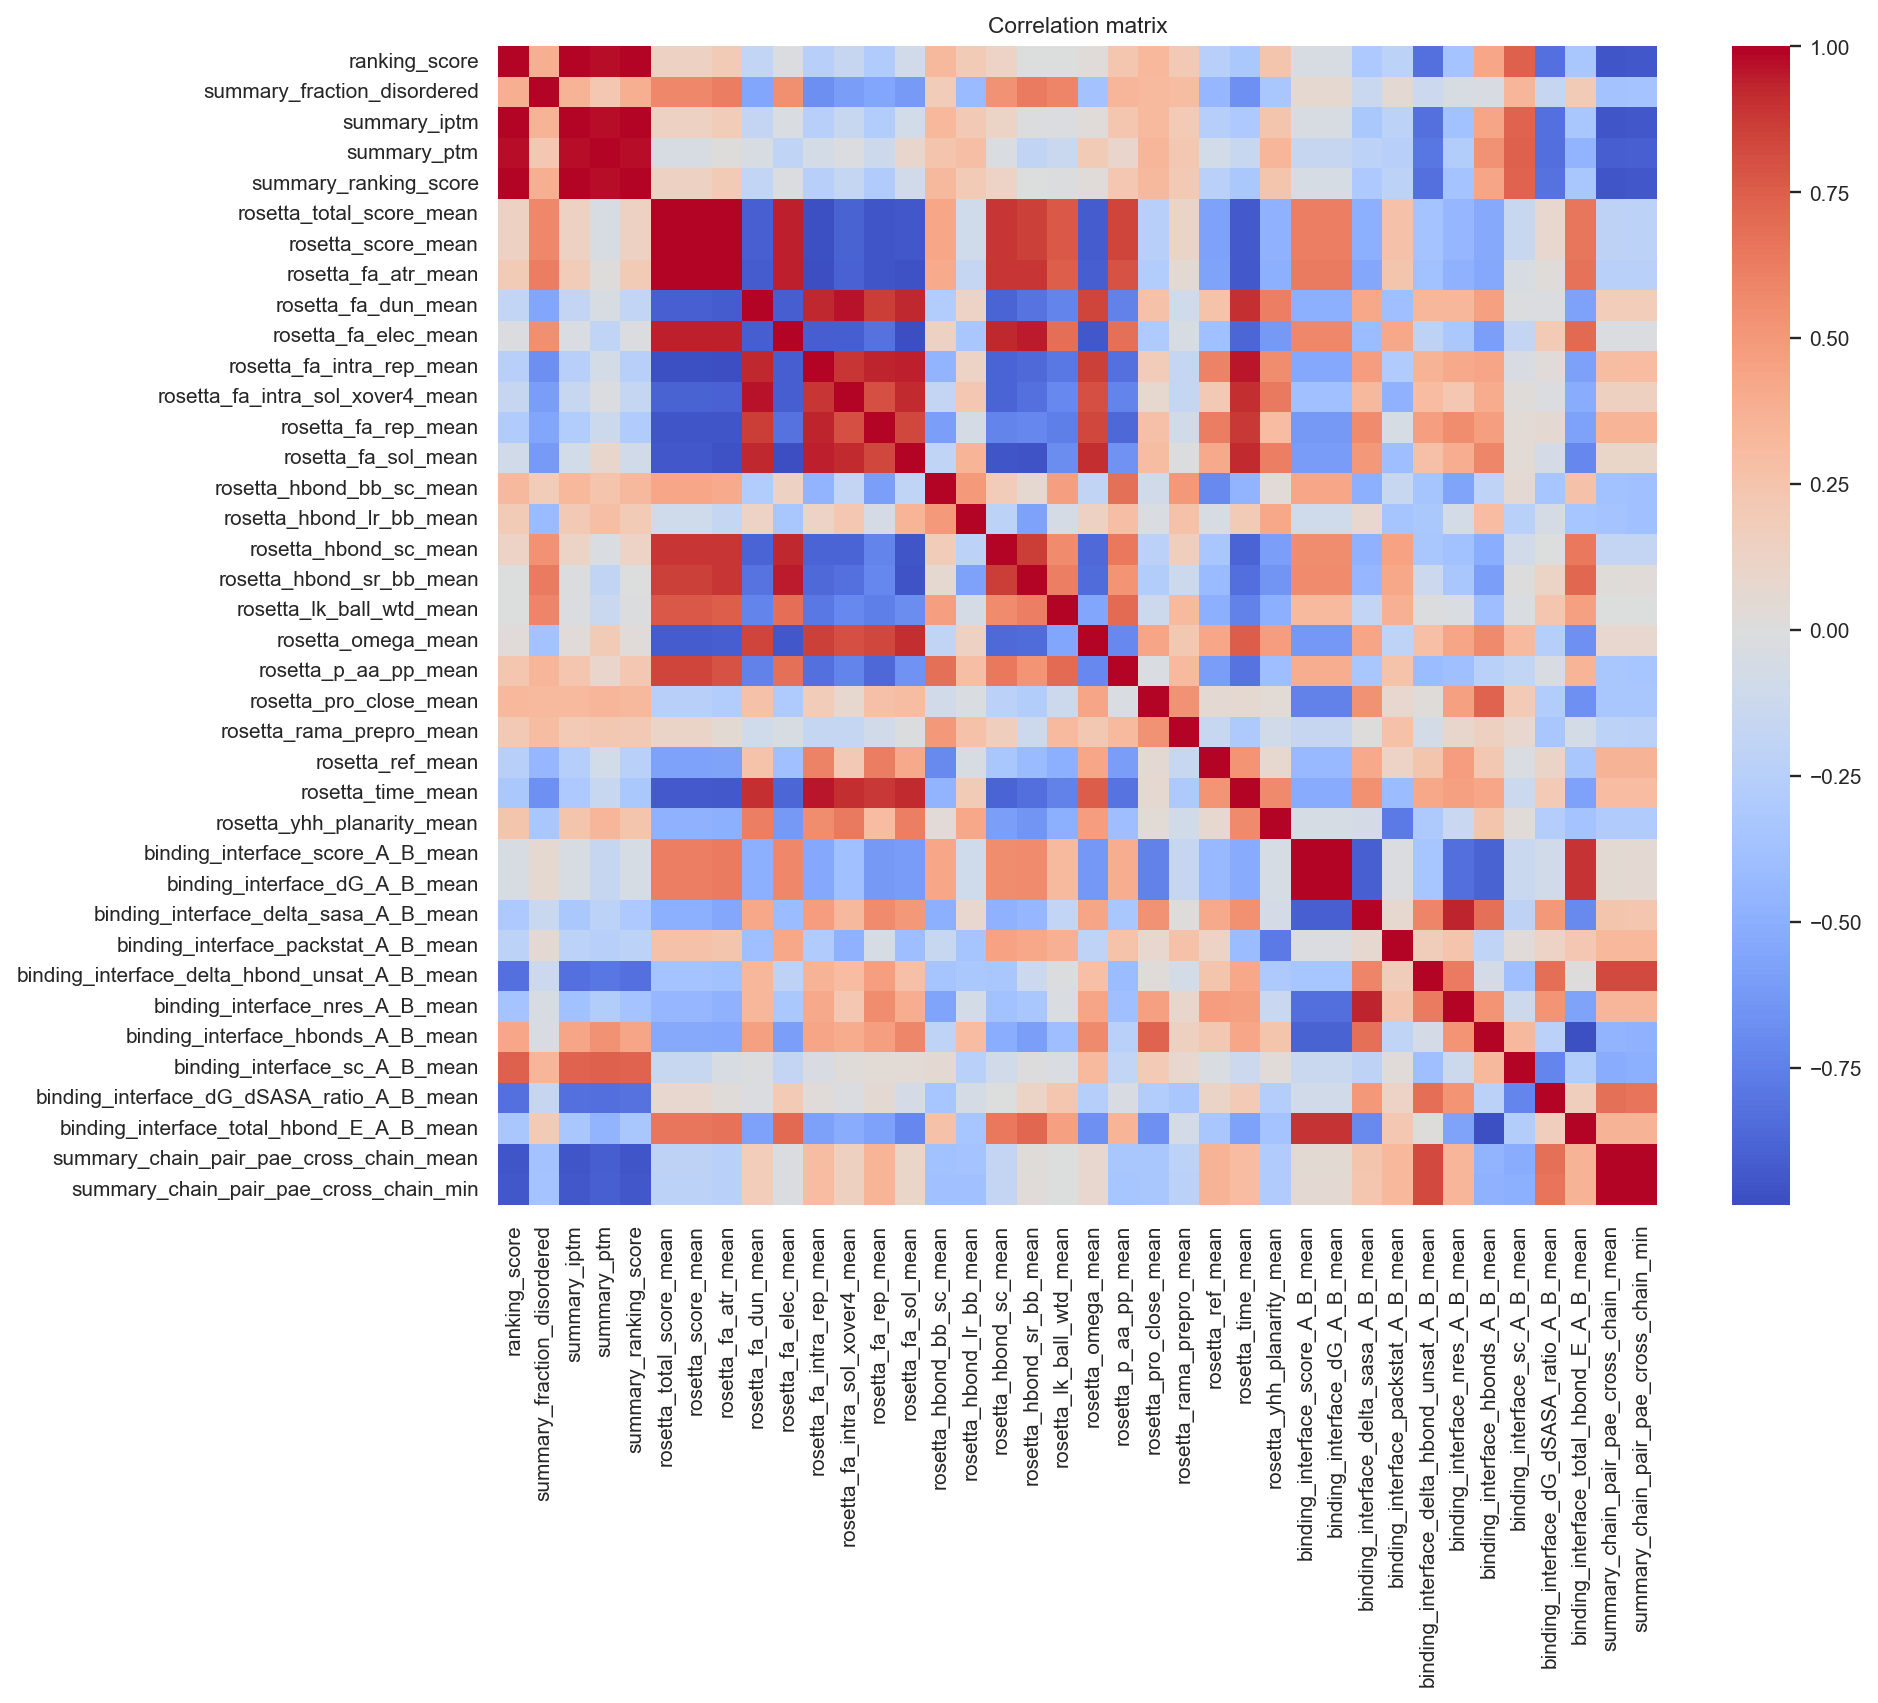

,metric_1,metric_2,pearson_correlation,abs_correlation
0,binding_interface_score_A_B_mean,binding_interface_dG_A_B_mean,1.000000,1.000000
1,rosetta_total_score_mean,rosetta_score_mean,1.000000,1.000000
2,ranking_score,summary_ranking_score,0.999933,0.999933
3,summary_chain_pair_pae_cross_chain_mean,summary_chain_pair_pae_cross_chain_min,0.999406,0.999406
4,ranking_score,summary_iptm,0.999312,0.999312
...,...,...,...,...
85,rosetta_fa_intra_rep_mean,rosetta_hbond_sr_bb_mean,-0.855752,0.855752
86,rosetta_fa_intra_rep_mean,rosetta_omega_mean,0.855585,0.855585
87,rosetta_score_mean,rosetta_hbond_sr_bb_mean,0.854616,0.854616
88,rosetta_total_score_mean,rosetta_hbond_sr_bb_mean,0.854616,0.854616


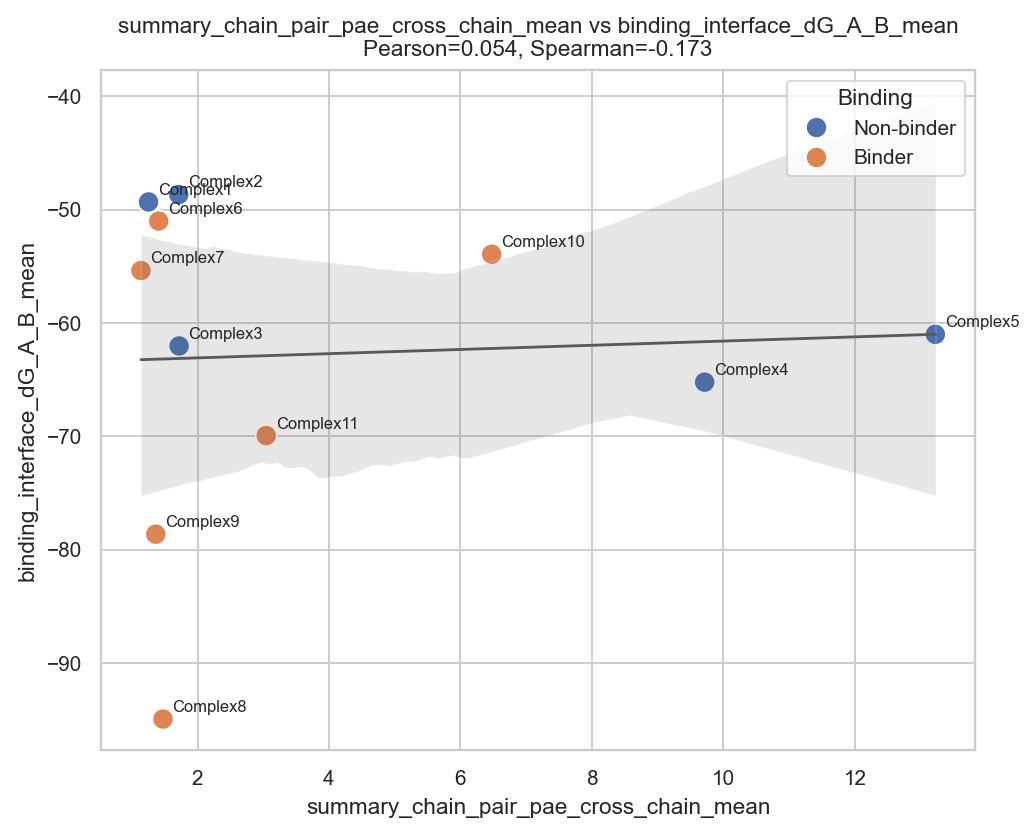

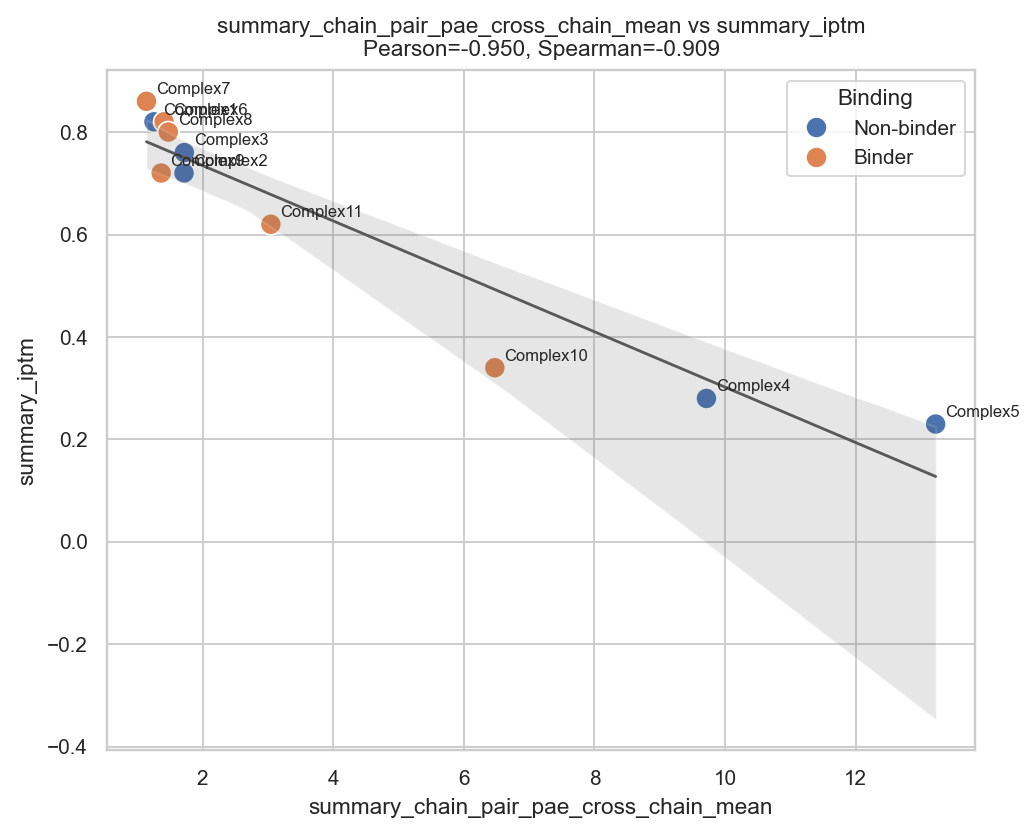

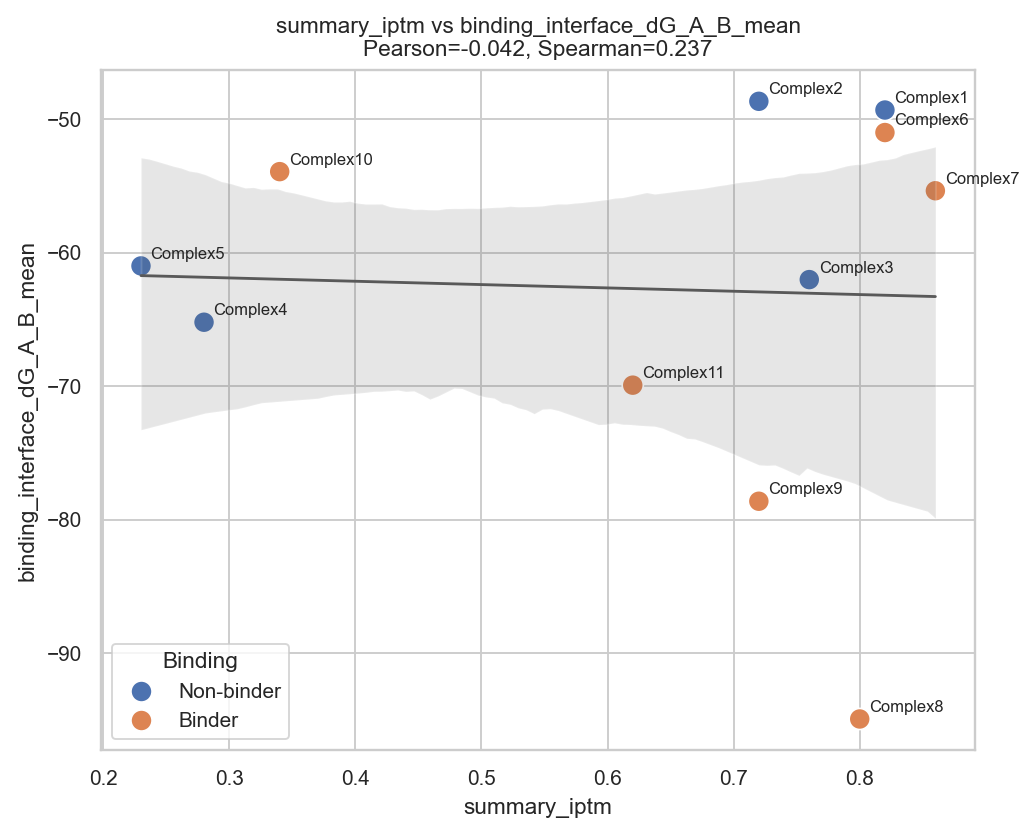

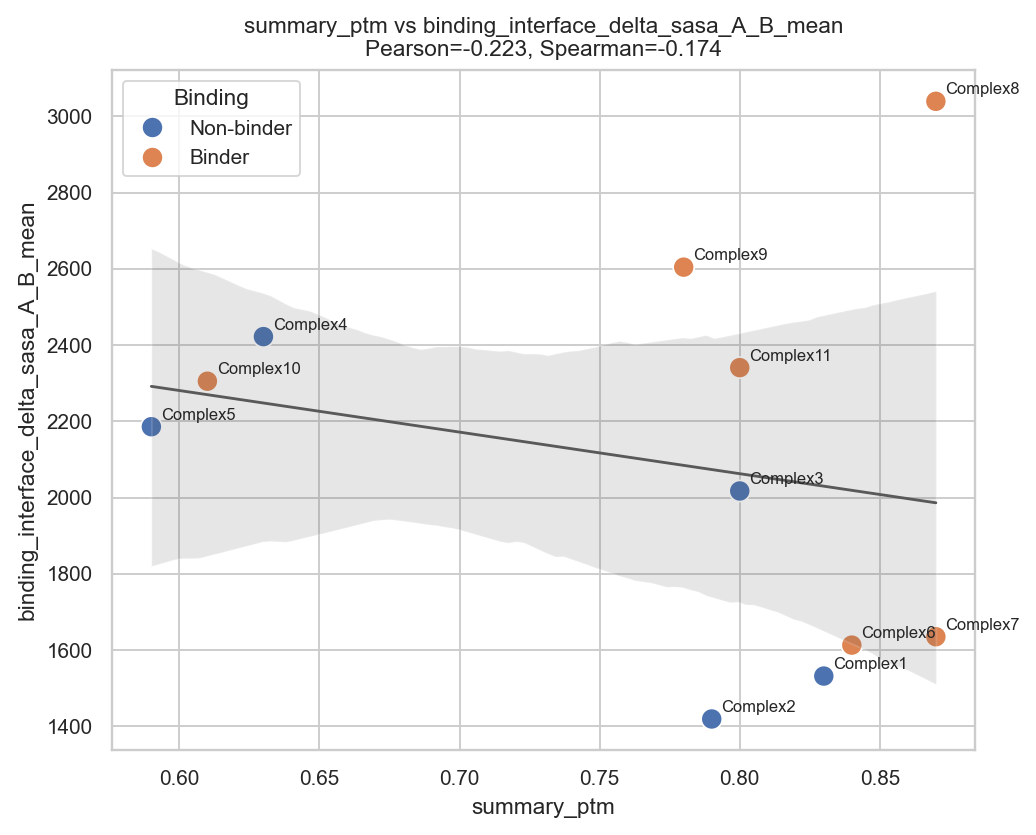

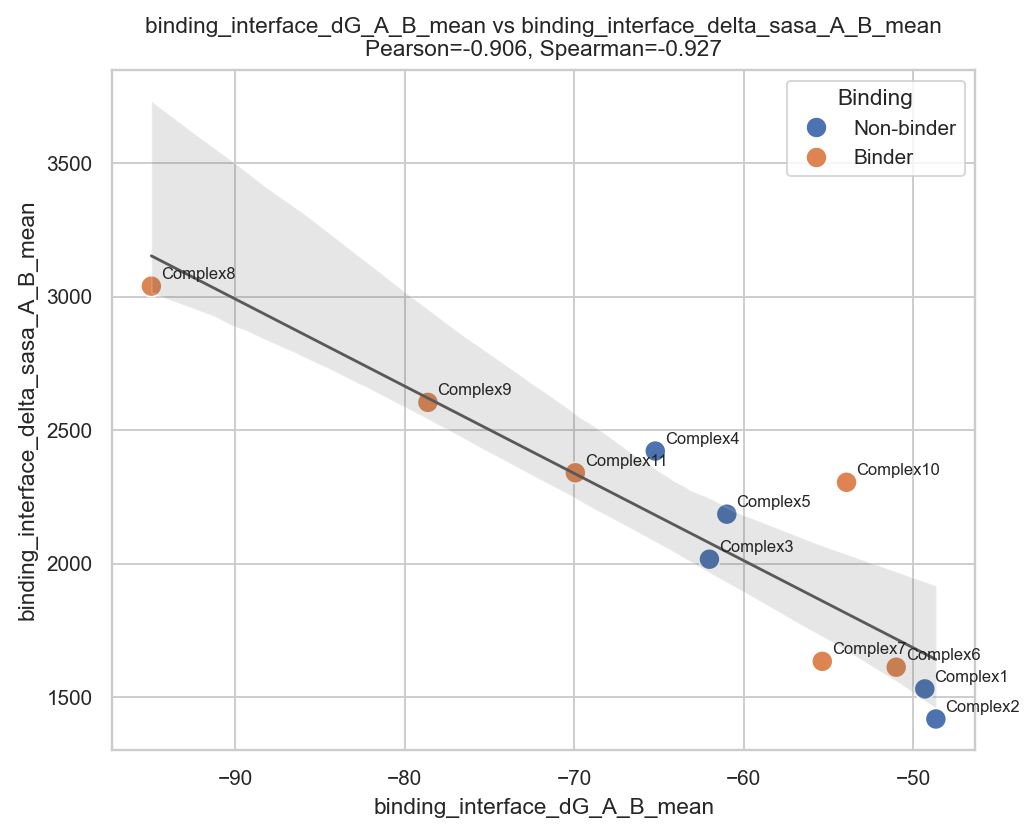

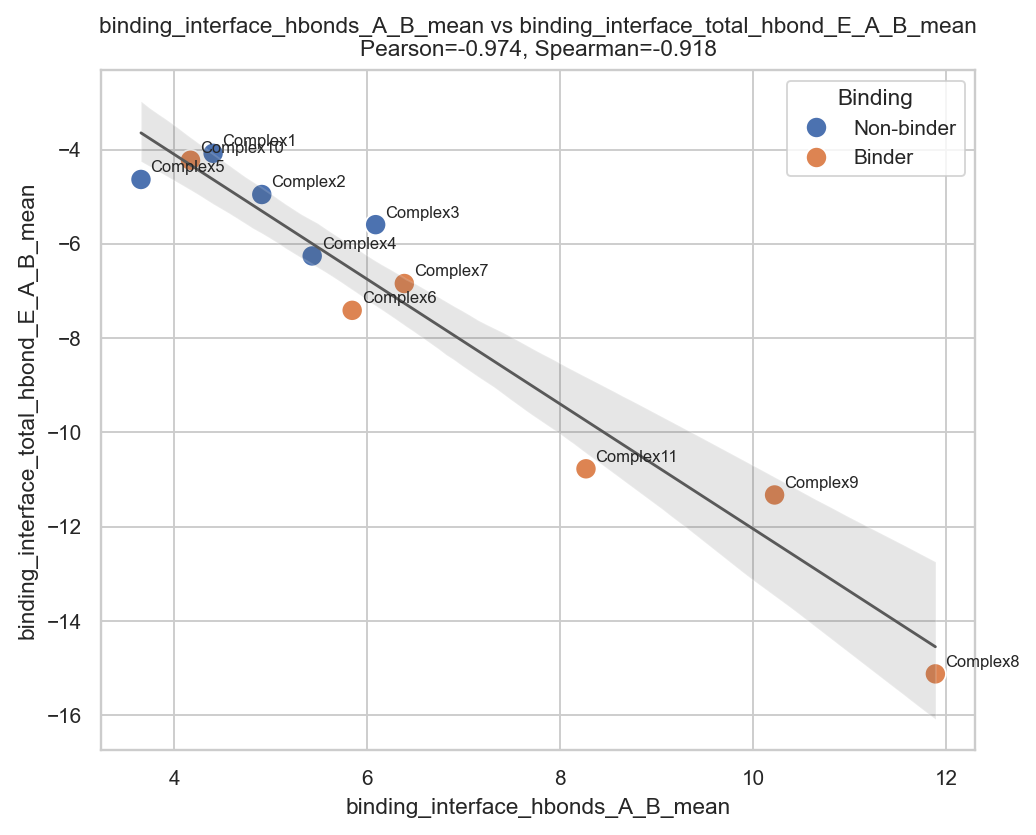

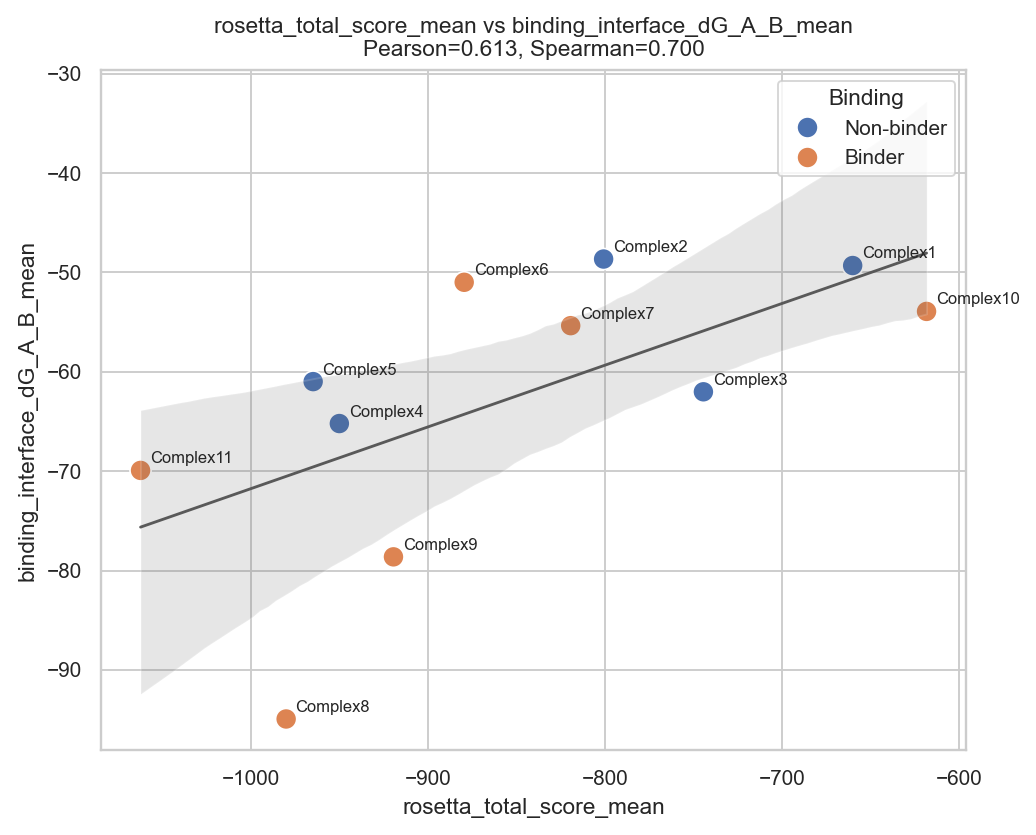

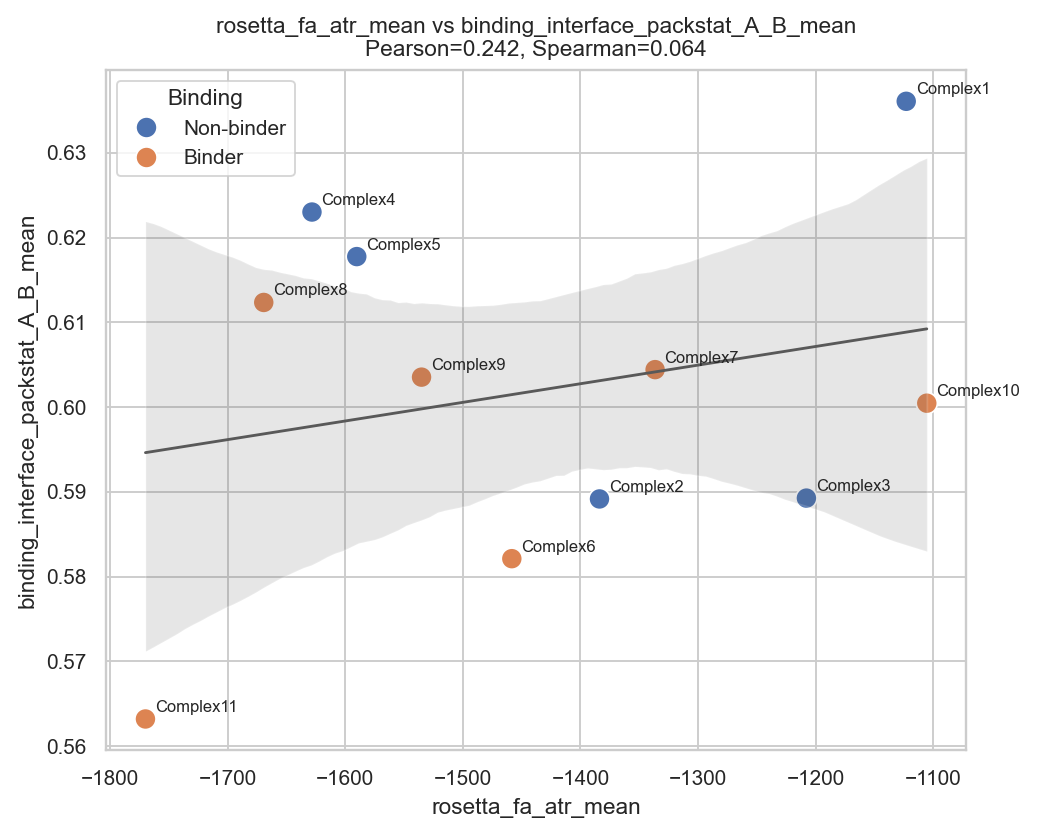

,x_metric,y_metric,pearson_r,spearman_r,n
0,summary_chain_pair_pae_cross_chain_mean,binding_interface_dG_A_B_mean,0.054180,-0.172727,11
1,summary_chain_pair_pae_cross_chain_mean,summary_iptm,-0.949562,-0.908685,11
2,summary_iptm,binding_interface_dG_A_B_mean,-0.041514,0.237445,11
3,summary_ptm,binding_interface_delta_sasa_A_B_mean,-0.222626,-0.173518,11
4,binding_interface_dG_A_B_mean,binding_interface_delta_sasa_A_B_mean,-0.906063,-0.927273,11
5,binding_interface_hbonds_A_B_mean,binding_interface_total_hbond_E_A_B_mean,-0.974150,-0.918182,11
6,rosetta_total_score_mean,binding_interface_dG_A_B_mean,0.613307,0.700000,11
7,rosetta_fa_atr_mean,binding_interface_packstat_A_B_mean,0.242033,0.063636,11


/opt/anaconda3/envs/prepare_proteins/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,ranking_score,inf
1,binding_interface_delta_sasa_A_B_mean,inf
2,rosetta_pro_close_mean,inf
3,rosetta_rama_prepro_mean,inf
4,rosetta_ref_mean,inf
5,rosetta_time_mean,inf
6,rosetta_yhh_planarity_mean,inf
7,binding_interface_score_A_B_mean,inf
8,binding_interface_dG_A_B_mean,inf
9,binding_interface_packstat_A_B_mean,inf


In [15]:
def compute_correlation_matrix(df_target, feature_cols, method='pearson'):
    work = df_target[feature_cols].apply(pd.to_numeric, errors='coerce')
    return work.corr(method=method)


def plot_correlation_matrix(corr_matrix, output_path, figsize=(12, 10)):
    plt.figure(figsize=figsize, dpi=170)
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True)
    plt.title('Correlation matrix')
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_selected_correlations(df_target, output_dir, binding_col='Binding'):
    correlation_specs = [
        ('summary_chain_pair_pae_cross_chain_mean', 'binding_interface_dG_A_B_mean'),
        ('summary_chain_pair_pae_cross_chain_mean', 'summary_iptm'),
        ('summary_iptm', 'binding_interface_dG_A_B_mean'),
        ('summary_ptm', 'binding_interface_delta_sasa_A_B_mean'),
        ('binding_interface_dG_A_B_mean', 'binding_interface_delta_sasa_A_B_mean'),
        ('binding_interface_hbonds_A_B_mean', 'binding_interface_total_hbond_E_A_B_mean'),
        ('rosetta_total_score_mean', 'binding_interface_dG_A_B_mean'),
        ('rosetta_fa_atr_mean', 'binding_interface_packstat_A_B_mean'),
    ]

    results = []
    for x_col, y_col in correlation_specs:
        if x_col not in df_target.columns or y_col not in df_target.columns:
            continue

        plot_df = df_target[[x_col, y_col, binding_col, 'DesignName']].copy()
        plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors='coerce')
        plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors='coerce')
        plot_df = plot_df.dropna(subset=[x_col, y_col, binding_col])
        if len(plot_df) < 3:
            continue

        pearson_r = plot_df[[x_col, y_col]].corr(method='pearson').iloc[0, 1]
        spearman_r = plot_df[[x_col, y_col]].corr(method='spearman').iloc[0, 1]
        results.append({
            'x_metric': x_col,
            'y_metric': y_col,
            'pearson_r': pearson_r,
            'spearman_r': spearman_r,
            'n': len(plot_df),
        })

        fig, ax = plt.subplots(figsize=(6.2, 5.0), dpi=170)
        sns.scatterplot(
            data=plot_df,
            x=x_col,
            y=y_col,
            hue=plot_df[binding_col].astype(int).map({0: 'Non-binder', 1: 'Binder'}),
            s=80,
            ax=ax,
        )
        sns.regplot(data=plot_df, x=x_col, y=y_col, scatter=False, color='0.35', line_kws={'linewidth': 1.2}, ax=ax)

        for _, row in plot_df.iterrows():
            ax.annotate(row['DesignName'], (row[x_col], row[y_col]), fontsize=7, xytext=(4, 3), textcoords='offset points')

        ax.set_title(f'{x_col} vs {y_col}\nPearson={pearson_r:.3f}, Spearman={spearman_r:.3f}')
        plt.tight_layout()
        filename = f"corr_{x_col}_vs_{y_col}.png".replace('/', '_')
        fig.savefig(output_dir / filename, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    return pd.DataFrame(results)


def compute_vif(df_target, feature_cols):
    X = df_target[feature_cols].apply(pd.to_numeric, errors='coerce').dropna().copy()

    low_variance = [c for c in X.columns if X[c].nunique() <= 1]
    if low_variance:
        X = X.drop(columns=low_variance)

    if X.empty:
        return pd.DataFrame(columns=['feature', 'VIF'])

    rows = []
    if X.shape[1] == 1:
        rows.append({'feature': X.columns[0], 'VIF': np.nan})
    else:
        for i, col in enumerate(X.columns):
            rows.append({
                'feature': col,
                'VIF': variance_inflation_factor(X.values, i)
            })

    vif_df = pd.DataFrame(rows).sort_values('VIF', ascending=False, na_position='last').reset_index(drop=True)
    return vif_df


corr_matrix = compute_correlation_matrix(df_labeled, metrics)
display(corr_matrix)
plot_correlation_matrix(corr_matrix, OUTPUT_DIR / 'correlation_matrix_numeric_metrics.png')
corr_matrix.to_csv(OUTPUT_DIR / 'correlation_matrix_numeric_metrics.csv')

# CODEX EDIT 2026-04-29: llista de parelles amb correlació alta
def list_high_correlation_pairs(corr_matrix, threshold=0.75):
    pairs = []
    cols = list(corr_matrix.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            value = corr_matrix.iloc[i, j]
            if pd.notna(value) and abs(value) > threshold:
                pairs.append({
                    'metric_1': cols[i],
                    'metric_2': cols[j],
                    'pearson_correlation': value,
                    'abs_correlation': abs(value),
                })

    out = pd.DataFrame(pairs).sort_values('abs_correlation', ascending=False).reset_index(drop=True)
    return out


high_corr_pairs_df = list_high_correlation_pairs(corr_matrix, threshold=0.85)
display(high_corr_pairs_df)
high_corr_pairs_df.to_csv(OUTPUT_DIR / 'high_correlation_pairs_over_0_85.csv', index=False)

selected_correlation_df = plot_selected_correlations(df_labeled, OUTPUT_DIR)
display(selected_correlation_df)
selected_correlation_df.to_csv(OUTPUT_DIR / 'selected_correlations.csv', index=False)

vif_df = compute_vif(df_labeled, metrics)
display(vif_df)
vif_df.to_csv(OUTPUT_DIR / 'vif_numeric_metrics.csv', index=False)


## Execució de la regressió logística

S'entrena un model de regressió logística amb regularització L1 i validació creuada leave-one-out (LOOCV) sobre el subconjunt de mètriques seleccionades. La regularització L1 afavoreix la dispersió dels coeficients i ajuda a identificar les mètriques amb major poder predictiu. S'inclou un permutation test per verificar que el rendiment del model és estadísticament superior a l'atzar.

=== FILTRAT DE COLUMNES ===
Columnes totals inicials: 53
Columnes finals: 20
Mètriques seleccionades:
['ranking_score', 'summary_iptm', 'summary_ptm', 'summary_ranking_score', 'summary_chain_pair_pae_cross_chain_mean', 'rosetta_total_score_mean', 'rosetta_fa_atr_mean', 'rosetta_fa_elec_mean', 'binding_interface_dG_A_B_mean', 'binding_interface_delta_sasa_A_B_mean', 'binding_interface_packstat_A_B_mean', 'binding_interface_hbonds_A_B_mean', 'binding_interface_sc_A_B_mean', 'binding_interface_total_hbond_E_A_B_mean']

=== MÈTRIQUES UTILITZADES EN LA REGRESSIÓ ===
ranking_score
summary_iptm
summary_ptm
summary_ranking_score
summary_chain_pair_pae_cross_chain_mean
rosetta_total_score_mean
rosetta_fa_atr_mean
rosetta_fa_elec_mean
binding_interface_dG_A_B_mean
binding_interface_delta_sasa_A_B_mean
binding_interface_packstat_A_B_mean
binding_interface_hbonds_A_B_mean
binding_interface_sc_A_B_mean
binding_interface_total_hbond_E_A_B_mean

=== DISTRIBUCIÓ DE CLASSES ===
0    5
1    6
Name: Bind

,C,accuracy,precision,recall,f1,auc
0,0.001,0.454545,0.0,0.0,0.0,0.5
1,0.010,0.454545,0.0,0.0,0.0,0.5
2,0.100,0.454545,0.0,0.0,0.0,0.5



Millor C seleccionat: 0.001

=== VALIDACIÓ ===
S'utilitza Leave-One-Out Cross Validation (LOOCV) amb Pipeline(StandardScaler + LogisticRegression).

=== RESULTATS GLOBALS LOOCV ===
Accuracy : 0.455
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
AUC      : 0.500

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.45      1.00      0.62         5
           1       0.00      0.00      0.00         6

    accuracy                           0.45        11
   macro avg       0.23      0.50      0.31        11
weighted avg       0.21      0.45      0.28        11



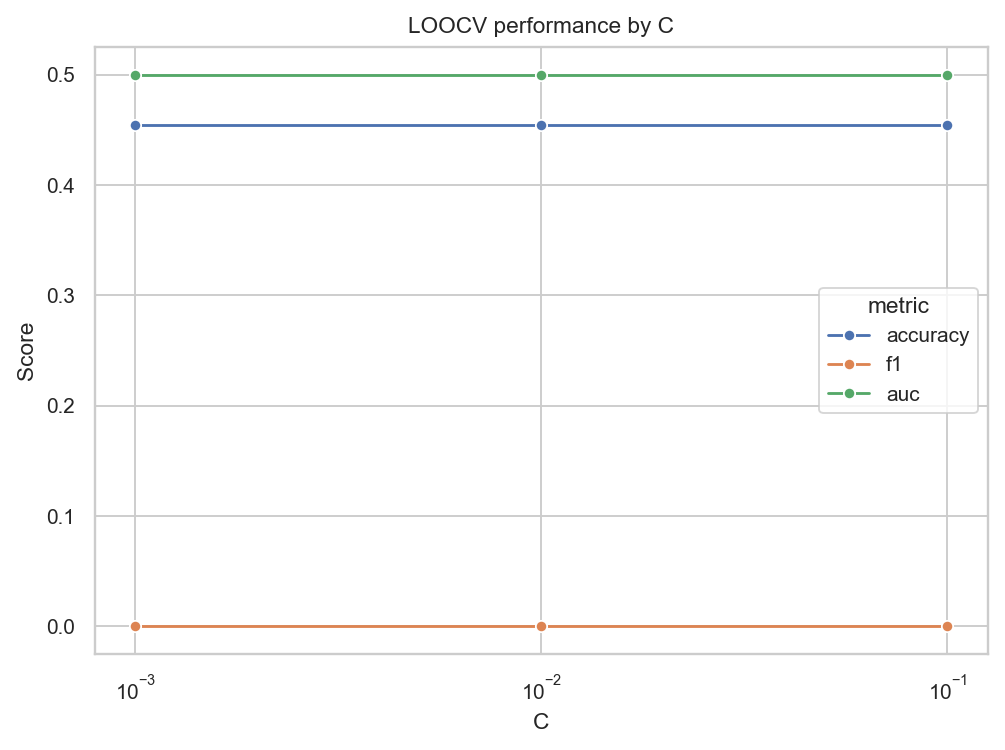

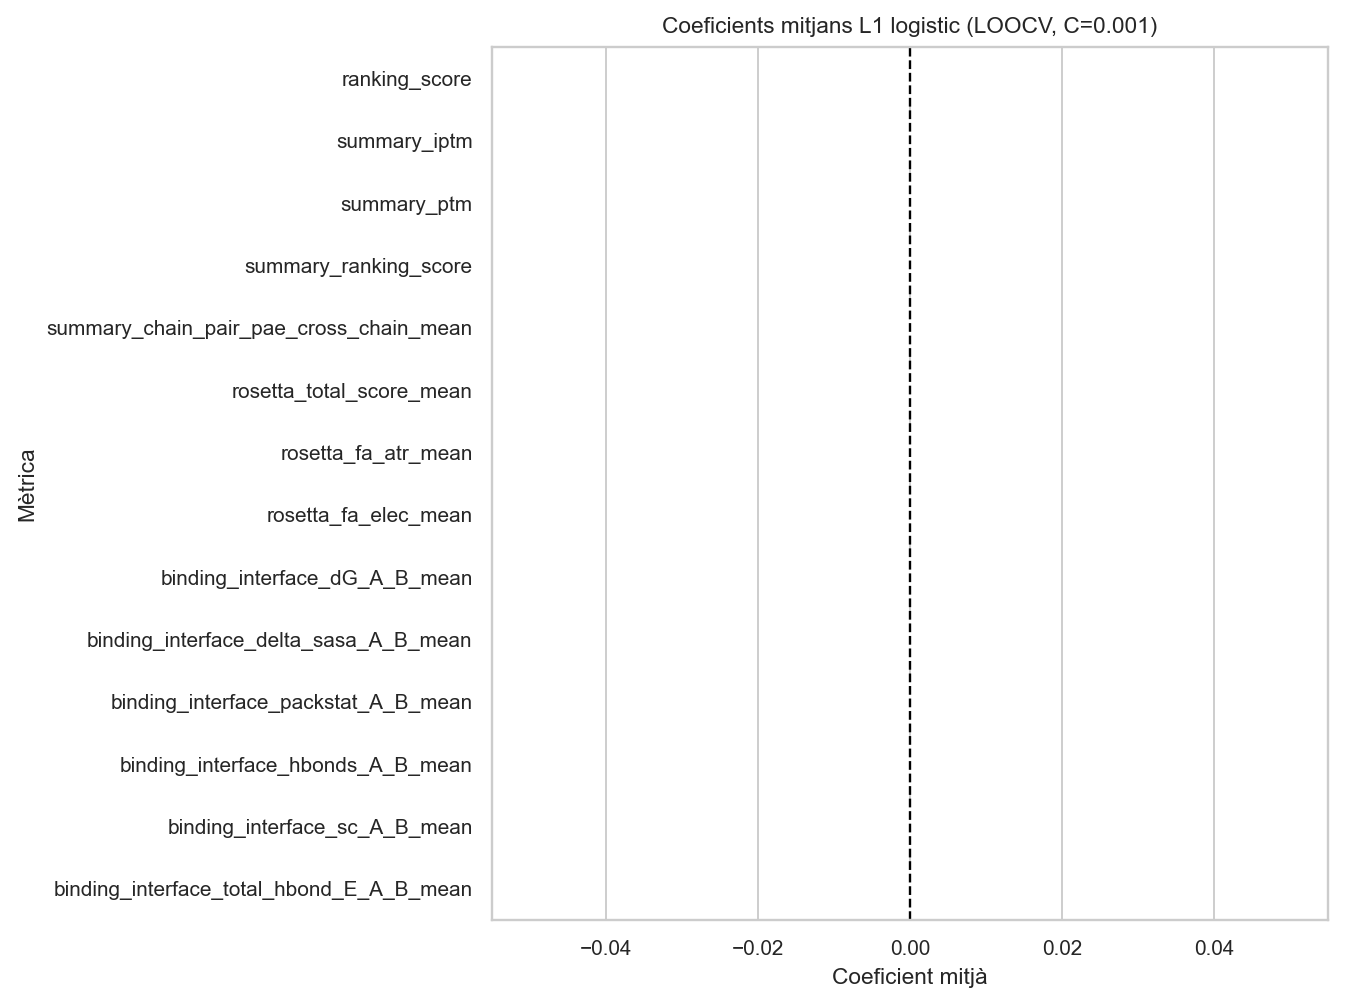

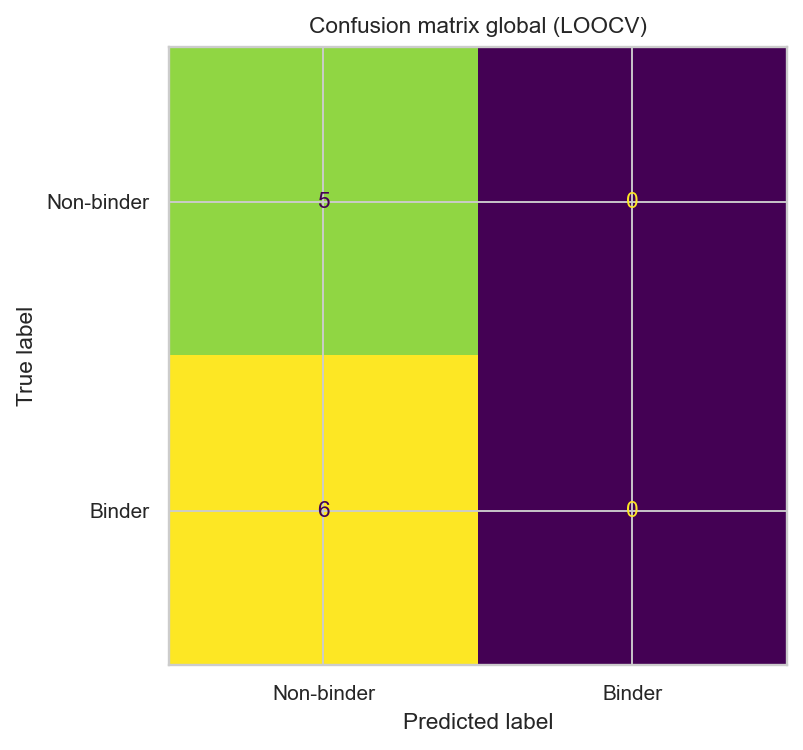

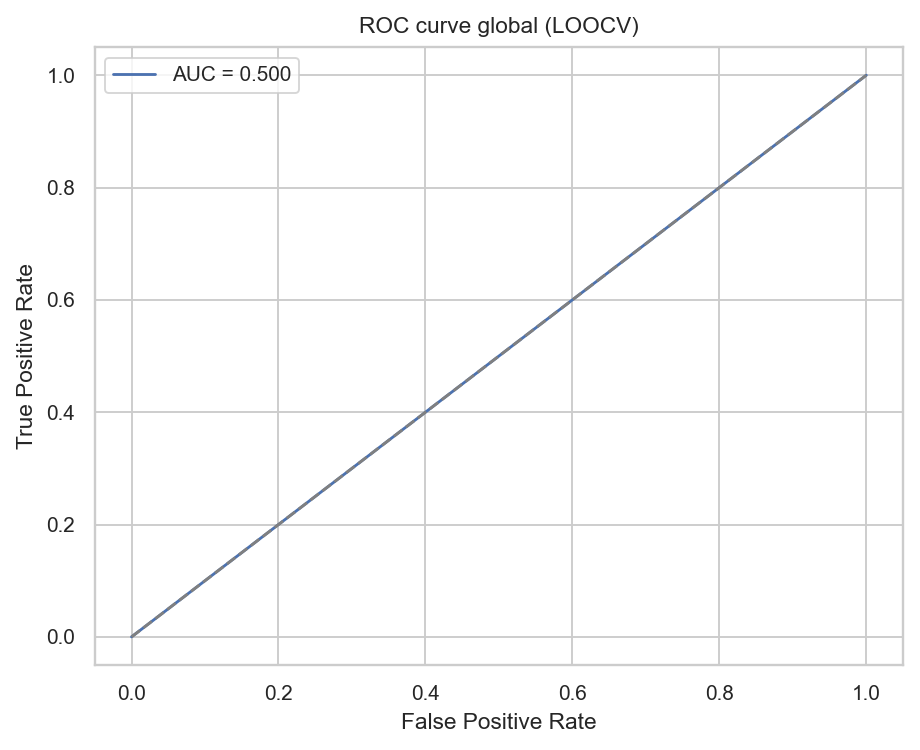

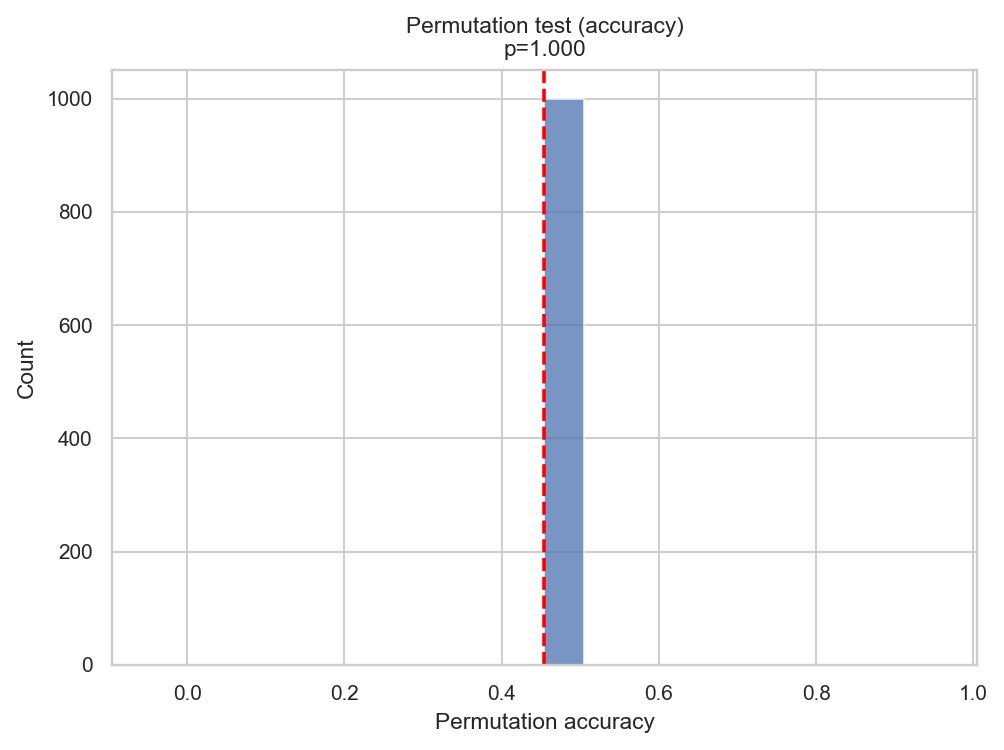

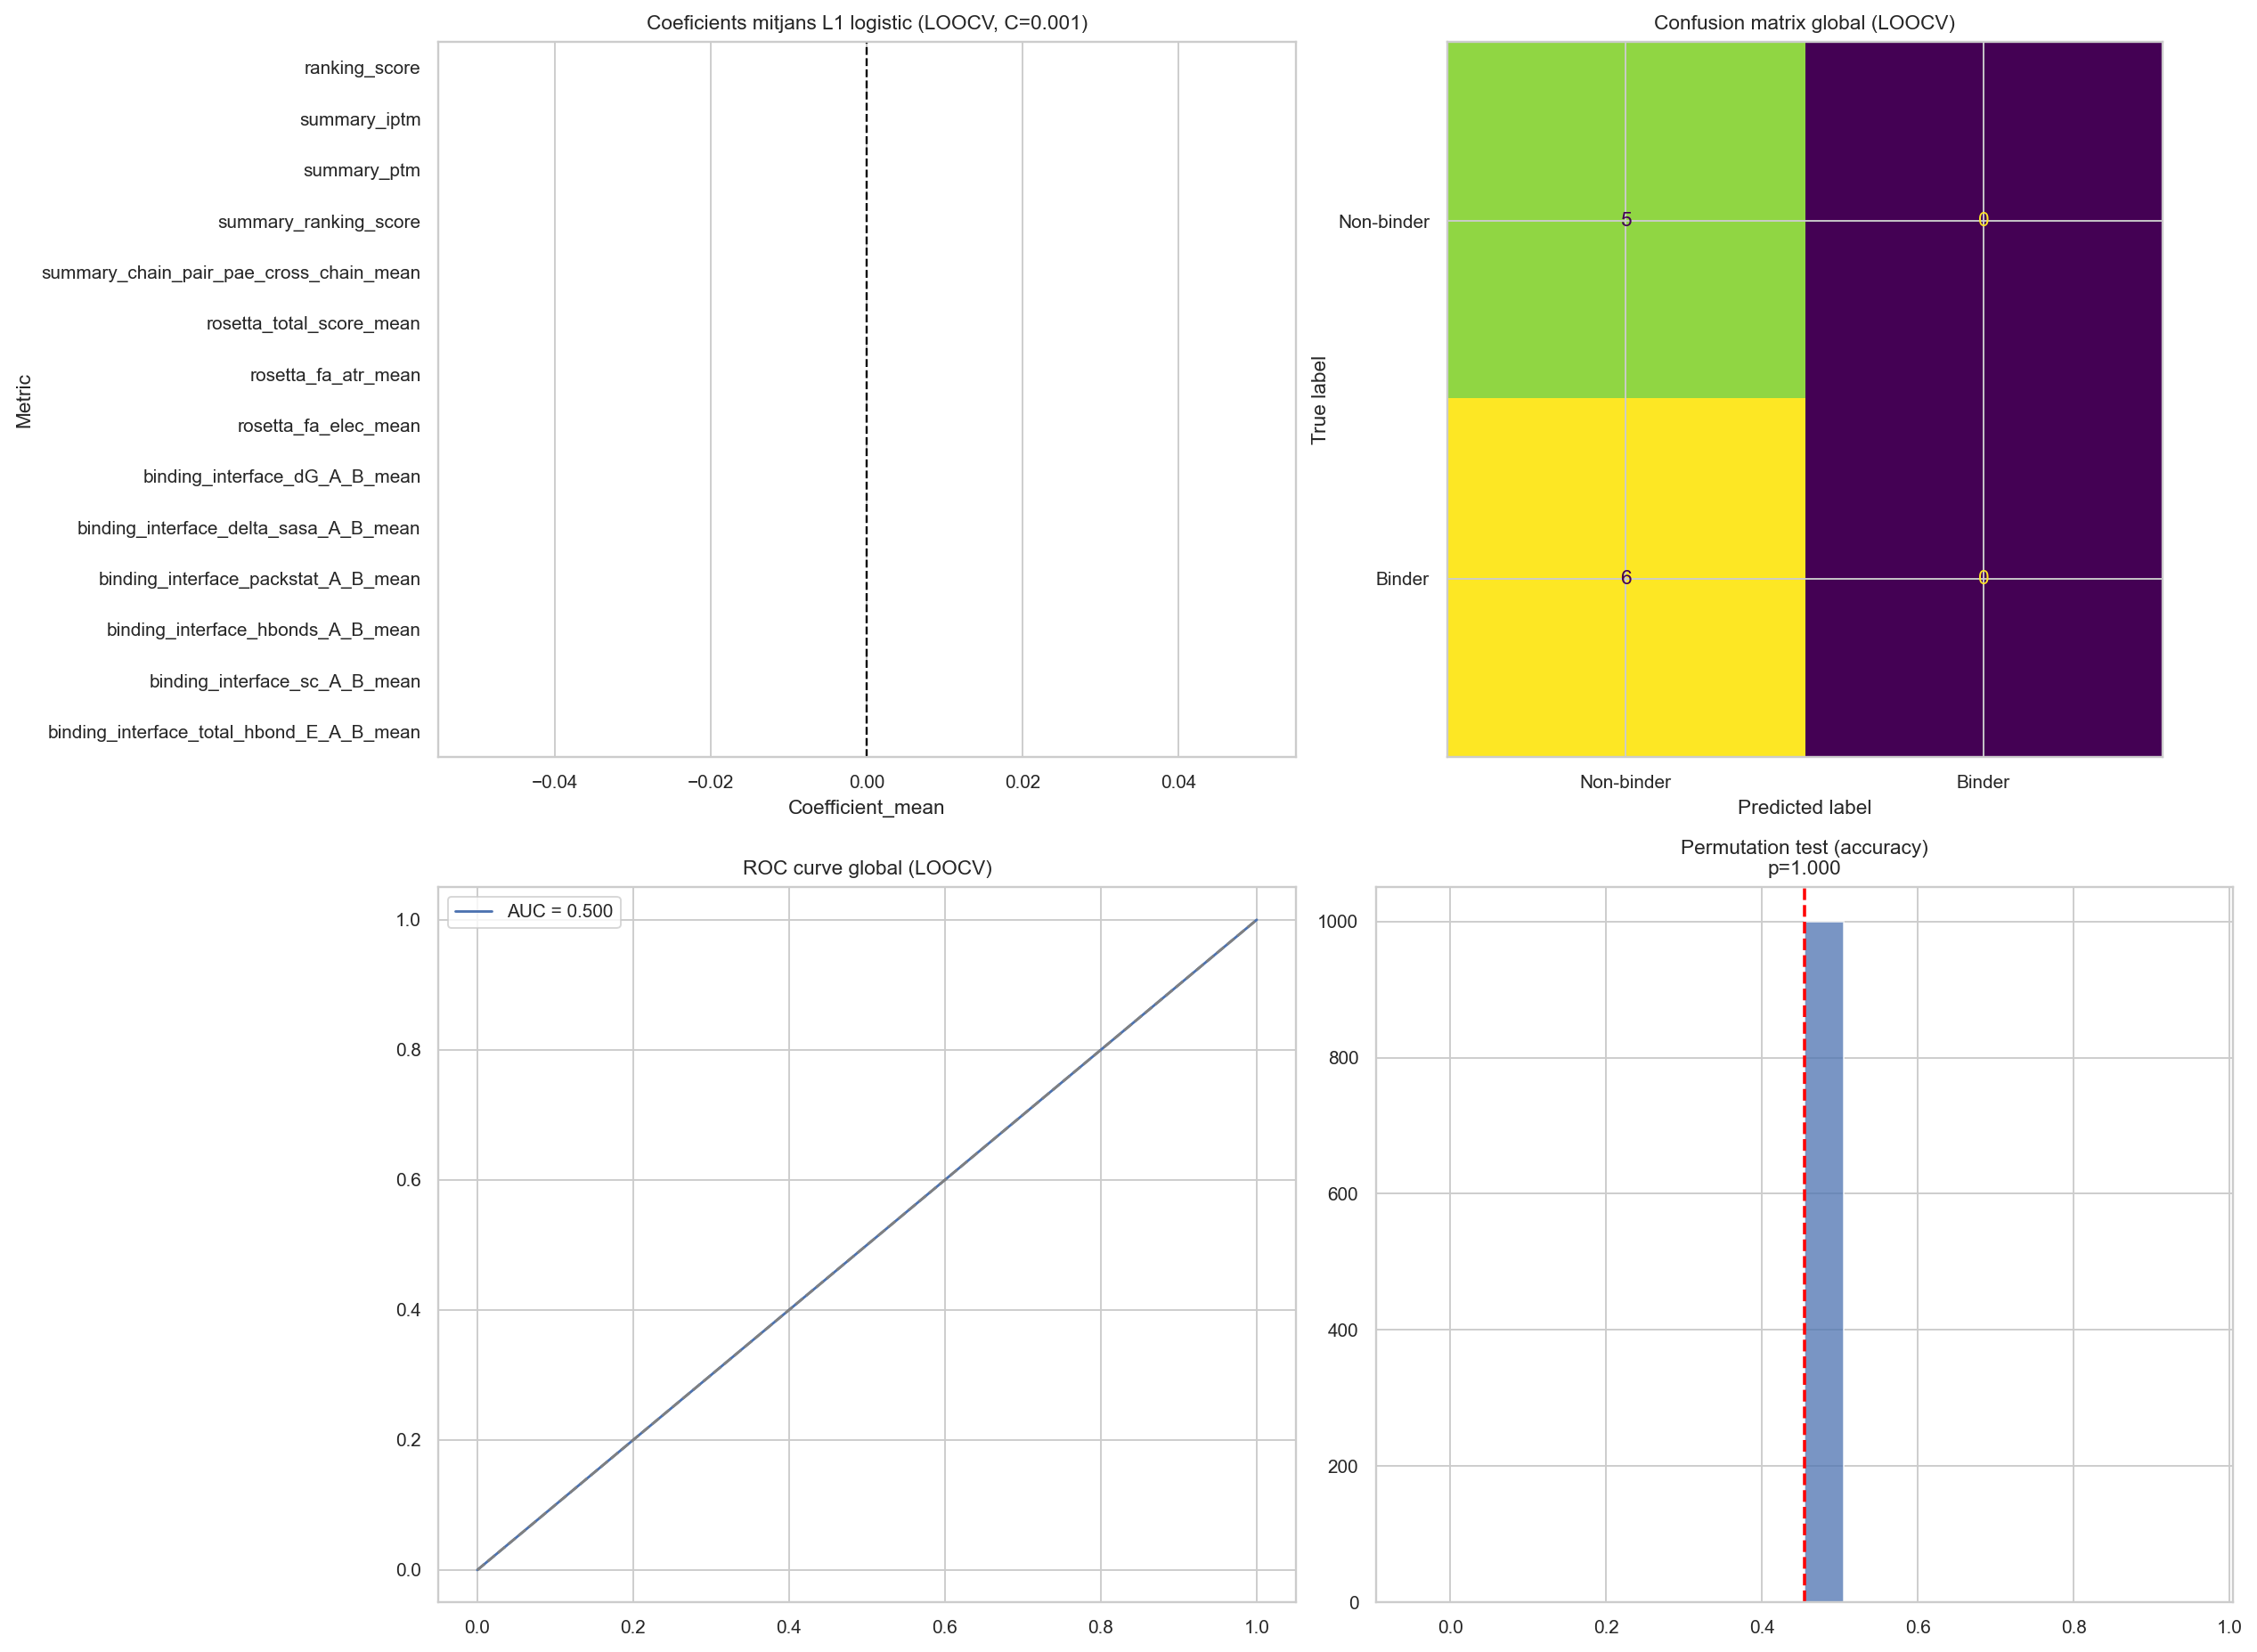

,C,accuracy,precision,recall,f1,auc
0,0.001,0.454545,0.0,0.0,0.0,0.5
1,0.010,0.454545,0.0,0.0,0.0,0.5
2,0.100,0.454545,0.0,0.0,0.0,0.5


,Metric,Coefficient_mean,Coefficient_std,AbsCoefficient_mean
0,ranking_score,0.0,0.0,0.0
1,summary_iptm,0.0,0.0,0.0
2,summary_ptm,0.0,0.0,0.0
3,summary_ranking_score,0.0,0.0,0.0
4,summary_chain_pair_pae_cross_chain_mean,0.0,0.0,0.0
5,rosetta_total_score_mean,0.0,0.0,0.0
6,rosetta_fa_atr_mean,0.0,0.0,0.0
7,rosetta_fa_elec_mean,0.0,0.0,0.0
8,binding_interface_dG_A_B_mean,0.0,0.0,0.0
9,binding_interface_delta_sasa_A_B_mean,0.0,0.0,0.0


,Target,DesignName,Binding,PredictedClass,PredictedProbability_Binder,CorrectPrediction
0,BBF-14,Complex1,0,0,0.5,True
1,BBF-14,Complex2,0,0,0.5,True
2,BBF-14,Complex3,0,0,0.5,True
3,BBF-14,Complex4,0,0,0.5,True
4,BBF-14,Complex5,0,0,0.5,True
5,BBF-14,Complex6,1,0,0.5,False
6,BBF-14,Complex7,1,0,0.5,False
7,BBF-14,Complex8,1,0,0.5,False
8,BBF-14,Complex9,1,0,0.5,False
9,BBF-14,Complex10,1,0,0.5,False


In [16]:
df_model, model_features = keep_selected_metrics(
    df_labeled,
    feature_cols=[
        'ranking_score',
        'summary_iptm',
        'summary_ptm',
        'summary_ranking_score',
        'summary_chain_pair_pae_cross_chain_mean',
        'rosetta_total_score_mean',
        'rosetta_fa_atr_mean',
        'rosetta_fa_elec_mean',
        'binding_interface_dG_A_B_mean',
        'binding_interface_delta_sasa_A_B_mean',
        'binding_interface_packstat_A_B_mean',
        'binding_interface_hbonds_A_B_mean',
        'binding_interface_sc_A_B_mean',
        'binding_interface_total_hbond_E_A_B_mean',
    ]
)

results = logistic_regression_visual(
    df_model,
    penalty='l1',
    c_grid=(0.001, 0.01, 0.1),
    permutation_n=1000,
    run_permutation=True,
    output_prefix='logistic_regression',
)

display(results['grid_results_df'])
display(results['coefficients'])
display(results['predictions'])


## Anàlisi de sensibilitat als outliers

S'identifiquen els dissenys que presenten valors atípics en un nombre elevat de mètriques, combinant el criteri IQR i el robust z-score. Per a cada disseny marcat com a outlier s'avalua l'impacte sobre els resultats del test de Mann-Whitney i la regressió logística retirant-los del dataset, per comprovar si les conclusions principals es mantenen.

,DesignName,iqr_outlier_metric_count,max_abs_robust_z,flagged_outlier
0,Complex8,2,3.685495,True
1,Complex5,1,16.877163,True
2,Complex4,0,11.730435,True
3,Complex10,0,6.979609,True
4,Complex1,0,3.030358,False
5,Complex9,0,2.107811,False
6,Complex11,0,1.950185,False
7,Complex3,0,1.450631,False
8,Complex2,0,1.235587,False
9,Complex7,0,1.180375,False


Outliers detectats: ['Complex8', 'Complex5', 'Complex4', 'Complex10']


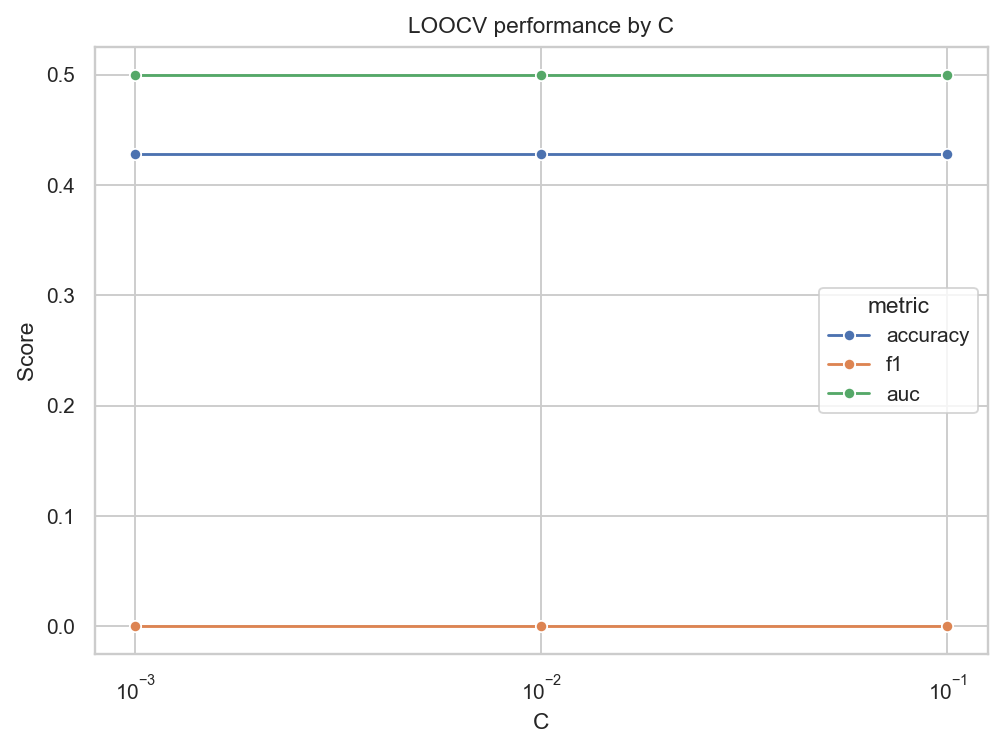

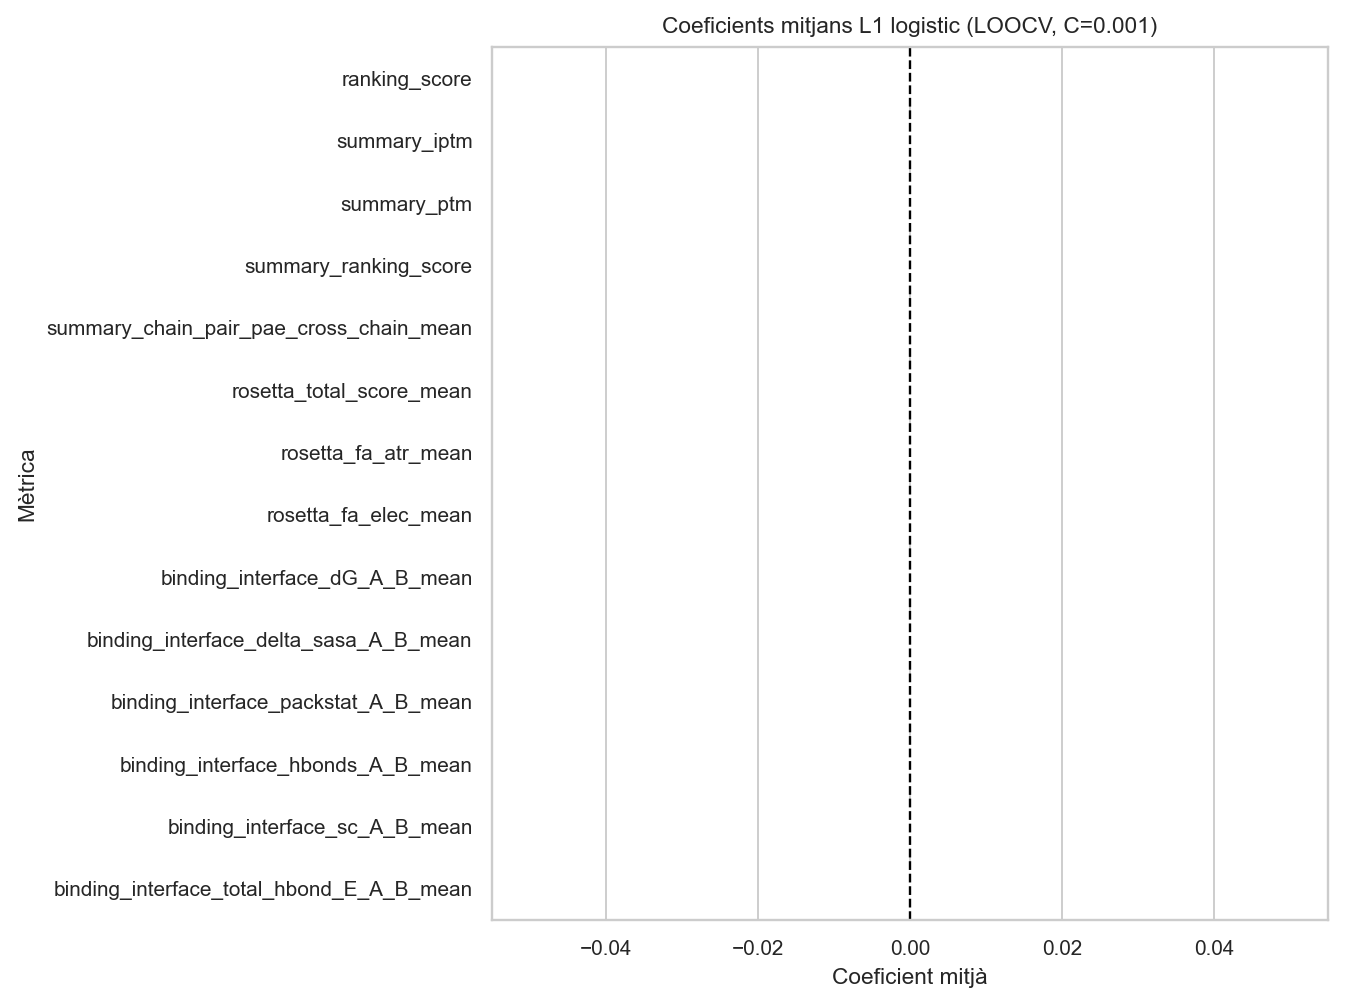

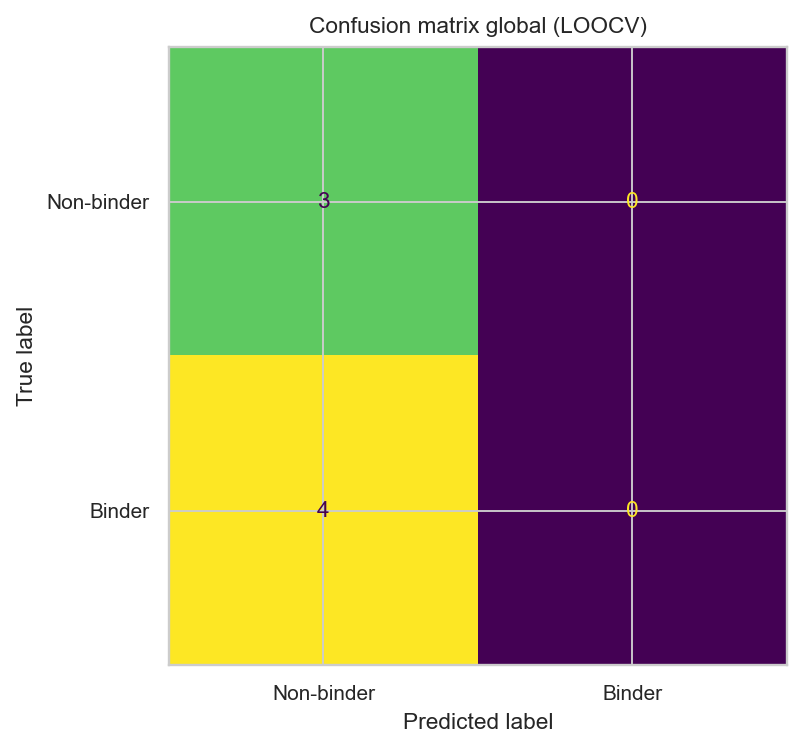

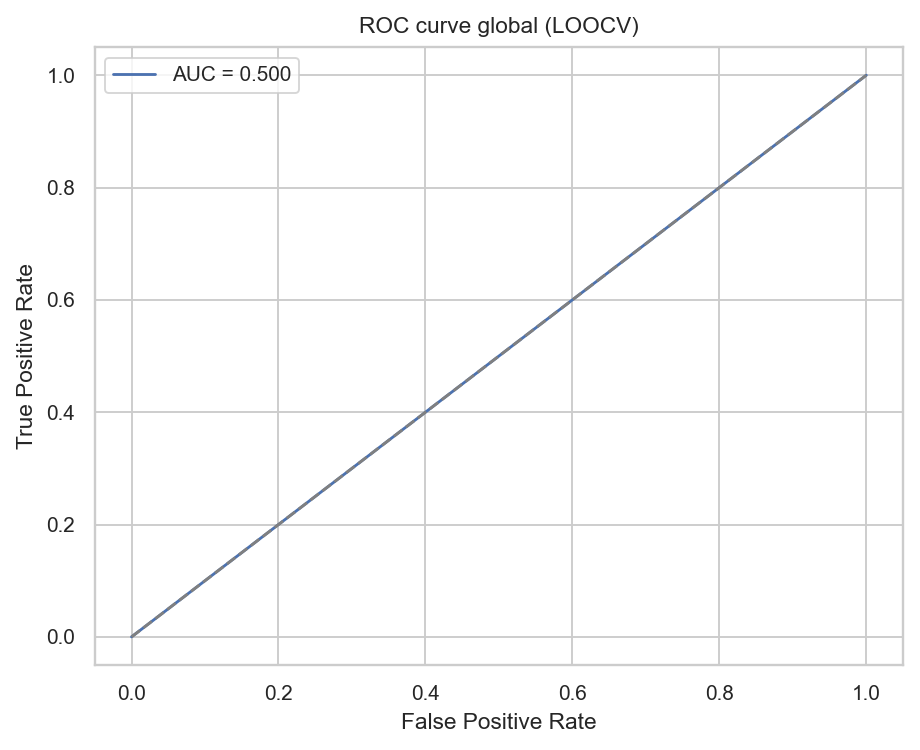

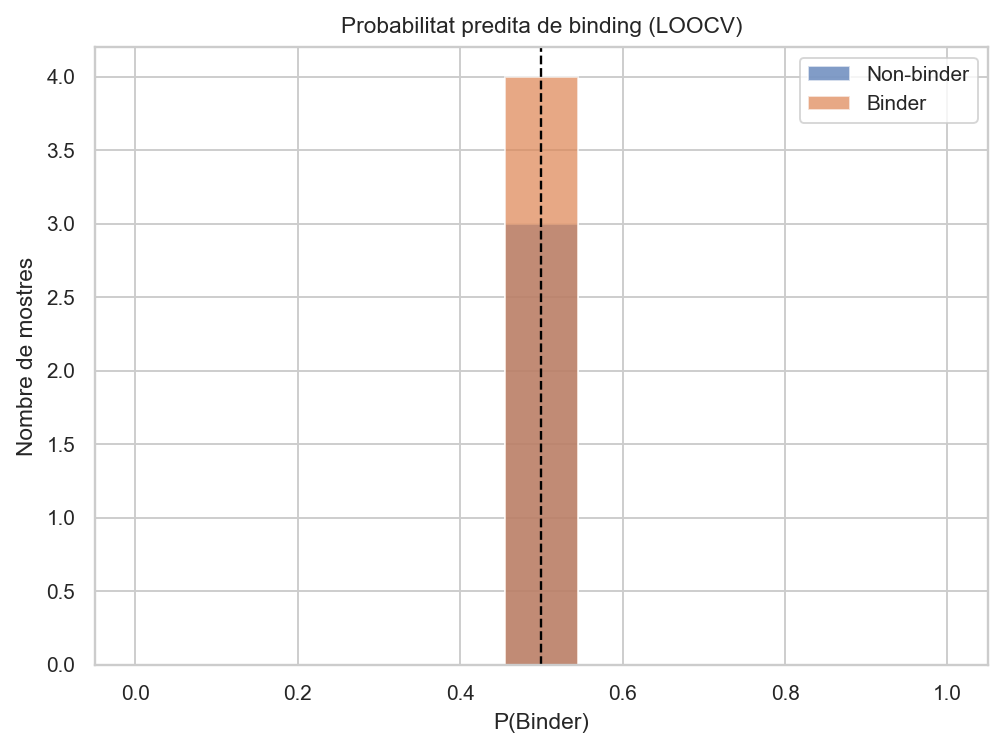

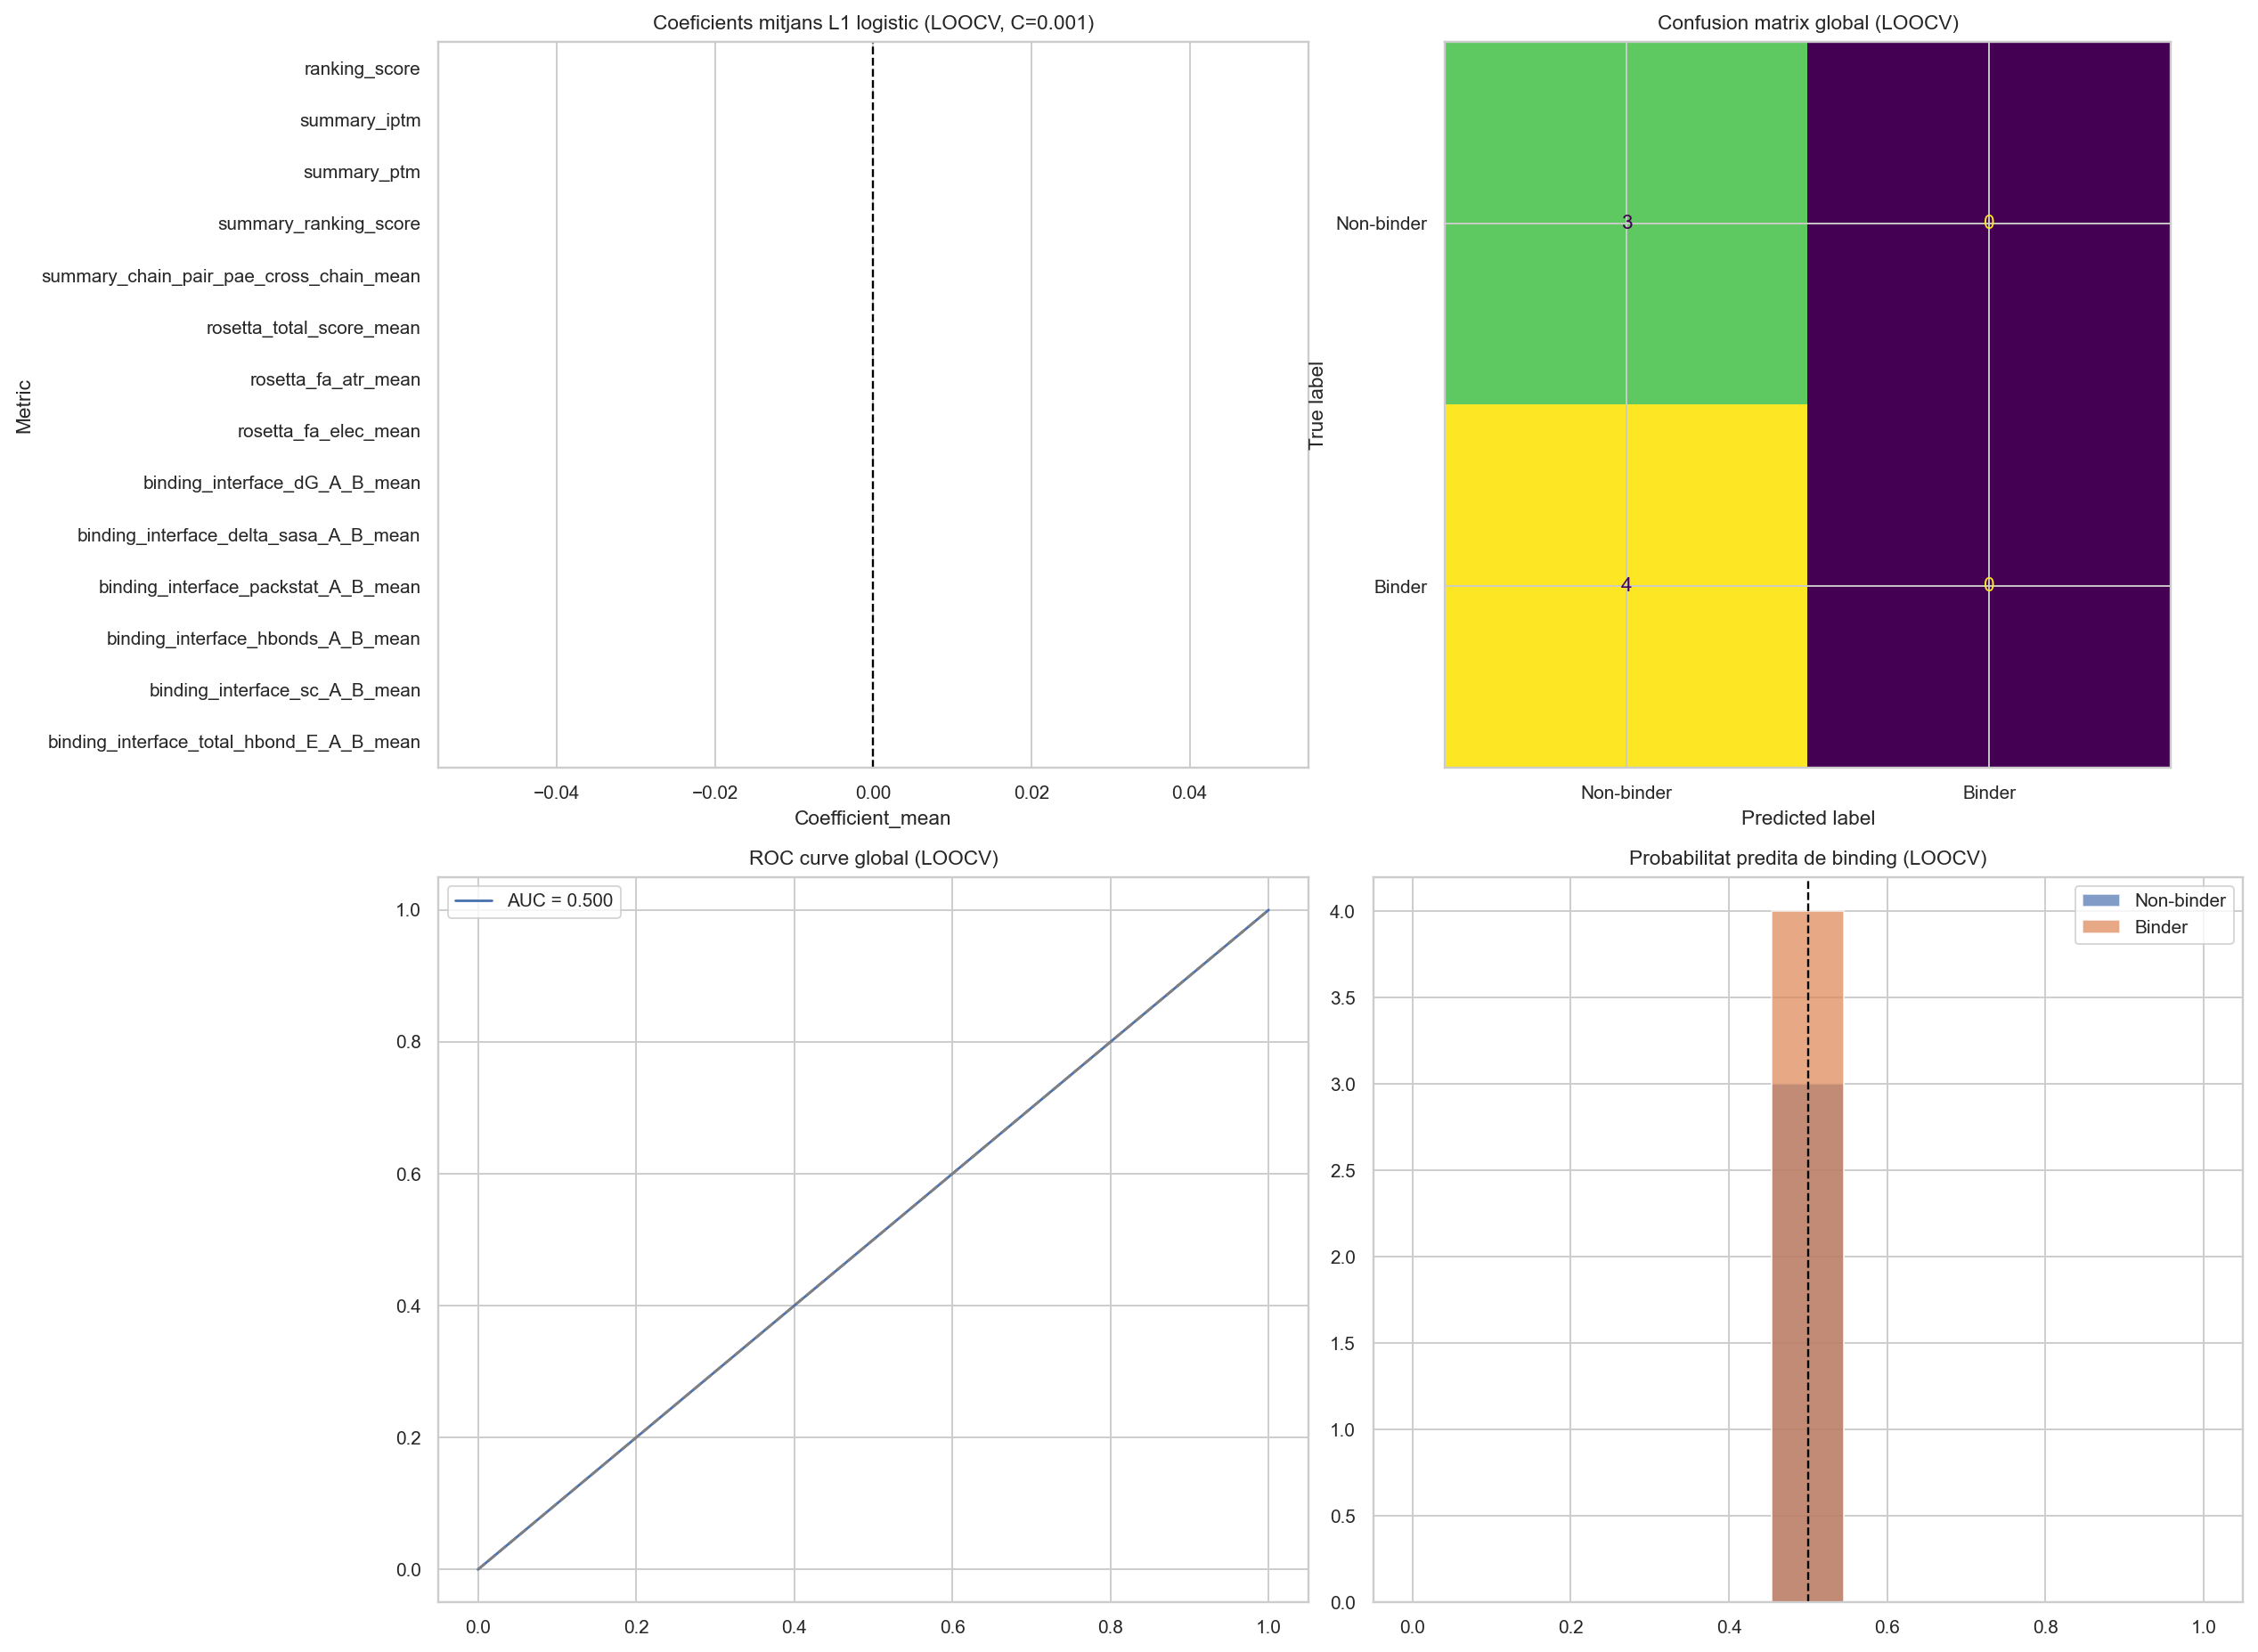

,analysis,dataset,n_removed_outliers,removed_models,accuracy,precision,recall,f1,auc,best_c,permutation_pvalue
0,logistic_loocv,full,0,,0.454545,0.0,0.0,0.0,0.5,0.001,1.0
1,logistic_loocv,without_outliers,4,"Complex8, Complex5, Complex4, Complex10",0.428571,0.0,0.0,0.0,0.5,0.001,NaN


,feature,p_value_raw_full,cliffs_delta_full,auc_metric_best_direction_full,p_value_raw_without_outliers,cliffs_delta_without_outliers,auc_metric_best_direction_without_outliers
0,binding_interface_total_hbond_E_A_B_mean,0.051948,-0.733333,0.866667,0.057143,-1.000000,1.000000
1,binding_interface_hbonds_A_B_mean,0.082251,0.666667,0.833333,0.114286,0.833333,0.916667
2,rosetta_hbond_lr_bb_mean,0.125541,0.600000,0.800000,0.114286,0.833333,0.916667
3,rosetta_fa_elec_mean,0.246753,-0.466667,0.733333,0.114286,-0.833333,0.916667
4,rosetta_hbond_sc_mean,0.246753,-0.466667,0.733333,0.114286,-0.833333,0.916667
5,rosetta_hbond_sr_bb_mean,0.246753,-0.466667,0.733333,0.228571,-0.666667,0.833333
6,binding_interface_packstat_A_B_mean,0.246753,-0.466667,0.733333,0.628571,-0.333333,0.666667
7,binding_interface_delta_sasa_A_B_mean,0.246753,0.466667,0.733333,0.228571,0.666667,0.833333
8,summary_ptm,0.271132,0.433333,0.716667,0.721277,0.250000,0.625000
9,summary_chain_pair_pae_cross_chain_min,0.272229,-0.433333,0.716667,0.721277,-0.250000,0.625000


In [17]:
# CODEX EDIT 2026-04-27: anàlisi de sensibilitat als outliers
def detect_outliers_robust(df_target, feature_cols, id_col='DesignName', iqr_k=1.5, robust_z_threshold=3.5, min_flagged_metrics=2):
    X = df_target[feature_cols].apply(pd.to_numeric, errors='coerce')
    summary = pd.DataFrame({id_col: df_target[id_col].values})

    iqr_counts = np.zeros(len(df_target), dtype=int)
    robust_z_max = np.zeros(len(df_target), dtype=float)

    for col in feature_cols:
        series = X[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if pd.notna(iqr) and iqr > 0:
            lo = q1 - iqr_k * iqr
            hi = q3 + iqr_k * iqr
            iqr_counts += ((series < lo) | (series > hi)).fillna(False).astype(int).values

        median = np.nanmedian(series)
        mad = np.nanmedian(np.abs(series - median))
        if pd.notna(mad) and mad > 0:
            robust_z = 0.6745 * (series - median) / mad
            robust_z_max = np.maximum(robust_z_max, np.nan_to_num(np.abs(robust_z), nan=0.0))

    summary['iqr_outlier_metric_count'] = iqr_counts
    summary['max_abs_robust_z'] = robust_z_max
    summary['flagged_outlier'] = (summary['iqr_outlier_metric_count'] >= min_flagged_metrics) | (summary['max_abs_robust_z'] >= robust_z_threshold)
    return summary.sort_values(['flagged_outlier', 'iqr_outlier_metric_count', 'max_abs_robust_z'], ascending=[False, False, False]).reset_index(drop=True)


def compare_full_vs_filtered_results(full_results, filtered_results, outlier_models):
    rows = [
        {
            'analysis': 'logistic_loocv',
            'dataset': 'full',
            'n_removed_outliers': 0,
            'removed_models': '',
            'accuracy': full_results['accuracy'],
            'precision': full_results['precision'],
            'recall': full_results['recall'],
            'f1': full_results['f1'],
            'auc': full_results['auc'],
            'best_c': full_results['best_c'],
            'permutation_pvalue': full_results['permutation_pvalue'],
        },
        {
            'analysis': 'logistic_loocv',
            'dataset': 'without_outliers',
            'n_removed_outliers': len(outlier_models),
            'removed_models': ', '.join(outlier_models),
            'accuracy': filtered_results['accuracy'] if filtered_results else np.nan,
            'precision': filtered_results['precision'] if filtered_results else np.nan,
            'recall': filtered_results['recall'] if filtered_results else np.nan,
            'f1': filtered_results['f1'] if filtered_results else np.nan,
            'auc': filtered_results['auc'] if filtered_results else np.nan,
            'best_c': filtered_results['best_c'] if filtered_results else np.nan,
            'permutation_pvalue': filtered_results['permutation_pvalue'] if filtered_results else np.nan,
        },
    ]
    return pd.DataFrame(rows)


outlier_summary_df = detect_outliers_robust(df_model, model_features)
display(outlier_summary_df)
outlier_summary_df.to_csv(OUTPUT_DIR / 'outlier_summary.csv', index=False)

outlier_models = outlier_summary_df.loc[outlier_summary_df['flagged_outlier'], 'DesignName'].tolist()
print('Outliers detectats:', outlier_models)

if len(outlier_models) > 0 and len(df_model) - len(outlier_models) >= 6:
    df_labeled_no_outliers = df_labeled[~df_labeled['DesignName'].isin(outlier_models)].copy()
    df_model_no_outliers = df_model[~df_model['DesignName'].isin(outlier_models)].copy()

    mannwhitney_no_outliers_df = mannwhitney_with_effects_auc(df_labeled_no_outliers, metrics)
    mannwhitney_no_outliers_df.to_csv(OUTPUT_DIR / 'mannwhitney_raw_effectsize_auc_fdr_without_outliers.csv', index=False)

    results_no_outliers = logistic_regression_visual(
        df_model_no_outliers,
        penalty='l1',
        c_grid=(0.001, 0.01, 0.1),
        permutation_n=250,
        run_permutation=False,
        verbose=False,
        output_prefix='logistic_regression_without_outliers',
    )
else:
    mannwhitney_no_outliers_df = pd.DataFrame()
    results_no_outliers = None

outlier_impact_df = compare_full_vs_filtered_results(results, results_no_outliers, outlier_models)
display(outlier_impact_df)
outlier_impact_df.to_csv(OUTPUT_DIR / 'outlier_impact_on_logistic.csv', index=False)

if not mannwhitney_no_outliers_df.empty:
    mw_compare = mannwhitney_fdr_df[['feature', 'p_value_raw', 'cliffs_delta', 'auc_metric_best_direction']].merge(
        mannwhitney_no_outliers_df[['feature', 'p_value_raw', 'cliffs_delta', 'auc_metric_best_direction']],
        on='feature',
        suffixes=('_full', '_without_outliers')
    )
    display(mw_compare.sort_values('p_value_raw_full').head(15))
    mw_compare.to_csv(OUTPUT_DIR / 'outlier_impact_on_mannwhitney.csv', index=False)


## Exportació dels resultats

Es guarden els CSVs amb els resultats de l'anàlisi: dataset normalitzat, p-values del test de Mann-Whitney, mides de l'efecte i AUC per mètrica, coeficients de la regressió logística, matriu de correlació, VIF i les prediccions del model.

In [18]:
df_labeled_norm.to_csv(OUTPUT_DIR / 'final_bbf14_normalized_minmax.csv', index=False)
pvals_df.to_csv(OUTPUT_DIR / 'mannwhitney_pvalues_raw_order_for_normalized_boxplot.csv', index=False)
mannwhitney_fdr_df.to_csv(OUTPUT_DIR / 'mannwhitney_raw_effectsize_auc_fdr.csv', index=False)
results['grid_results_df'].to_csv(OUTPUT_DIR / 'logistic_regularization_grid_loocv.csv', index=False)
results['coefficients'].to_csv(OUTPUT_DIR / 'logistic_regression_coefficients.csv', index=False)
results['predictions'].to_csv(OUTPUT_DIR / 'logistic_regression_predictions.csv', index=False)

summary_df = pd.DataFrame([{
    'accuracy': results['accuracy'],
    'precision': results['precision'],
    'recall': results['recall'],
    'f1': results['f1'],
    'auc': results['auc'],
    'best_c': results['best_c'],
    'penalty': results['penalty'],
    'permutation_score': results['permutation_score'],
    'permutation_pvalue': results['permutation_pvalue'],
}])
summary_df.to_csv(OUTPUT_DIR / 'logistic_regression_summary.csv', index=False)

corr_matrix.to_csv(OUTPUT_DIR / 'correlation_matrix_numeric_metrics.csv')
selected_correlation_df.to_csv(OUTPUT_DIR / 'selected_correlations.csv', index=False)
high_corr_pairs_df.to_csv(OUTPUT_DIR / 'high_correlation_pairs_over_0_75.csv', index=False)
vif_df.to_csv(OUTPUT_DIR / 'vif_numeric_metrics.csv', index=False)
outlier_summary_df.to_csv(OUTPUT_DIR / 'outlier_summary.csv', index=False)
outlier_impact_df.to_csv(OUTPUT_DIR / 'outlier_impact_on_logistic.csv', index=False)

print(f'Results saved to: {OUTPUT_DIR}')


Results saved to: /Users/bertaguiu/projects/Scripts/bbf14/final_bbf14_bindcraft_style_outputs
